# Test Trace And Answer Analysis

This notebook analyzes the test-set oracle traces and inference runs under:

- `outputs/inference/test_oracle`
- `outputs/inference/current_lvar_model`
- `outputs/oracle_dataset/test`

It is intentionally discovery-driven: it scans the directories, parses run metadata from paths, and builds reusable dataframes for accuracy, trace structure, selected patches/regions, cross-entropy reductions, correctness-conditioned trace analysis, and decoding entropy. The full LVAR model + controller run is included alongside oracle runs in the shared result tables.


In [1]:
%matplotlib inline

from collections import Counter
import json
import math
from pathlib import Path
import re
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path("/home/csalt/Haider/DVLM/lvar")]
ROOT = next((p.resolve() for p in ROOT_CANDIDATES if (p / "outputs/inference/test_oracle").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Could not locate repo root containing outputs/inference/test_oracle")

INFERENCE_ROOT = ROOT / "outputs/inference/test_oracle"
FULL_LVAR_ROOT = ROOT / "outputs/inference/current_lvar_model"
TRACE_ROOT = ROOT / "outputs/oracle_dataset/test"

print(f"ROOT: {ROOT}")
print(f"INFERENCE_ROOT exists: {INFERENCE_ROOT.exists()} -> {INFERENCE_ROOT}")
print(f"FULL_LVAR_ROOT exists: {FULL_LVAR_ROOT.exists()} -> {FULL_LVAR_ROOT}")
print(f"TRACE_ROOT exists: {TRACE_ROOT.exists()} -> {TRACE_ROOT}")

ROOT: /home/csalt/Haider/DVLM/lvar
INFERENCE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle
FULL_LVAR_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/inference/current_lvar_model
TRACE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/oracle_dataset/test


## Helpers

The helpers below normalize naming across paths, load JSONL safely, and derive trace-level metrics from both high-level decisions and primitive trace actions.

In [2]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_jsonl(path):
    path = Path(path)
    rows = []
    bad_rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append({
                    "path": str(path),
                    "line_number": line_number,
                    "error": str(exc),
                    "context": stripped[max(0, exc.pos - 100): exc.pos + 100],
                })
    return rows, bad_rows


def clean_ckpt_name(value):
    if value is None:
        return None
    value = str(value)
    value = value.replace("mined_by_", "").replace("evaluated_by_", "")
    value = value.replace("_ckpt", "")
    return value


def pretty_variant(value):
    mapping = {
        "raw": "raw",
        "filtered_cap": "filtered (cap)",
        "filtered_no_cap": "filtered (no cap)",
    }
    return mapping.get(str(value), str(value))


def parse_inference_summary_path(path):
    parts = Path(path).parts
    mined_by = next((clean_ckpt_name(p) for p in parts if p.startswith("mined_by_")), None)
    evaluated_by = next((clean_ckpt_name(p) for p in parts if p.startswith("evaluated_by_")), None)
    variant_dir = next((p.replace("trace_variant_", "") for p in parts if p.startswith("trace_variant_")), None)
    return mined_by, evaluated_by, variant_dir


def parse_trace_path(path):
    path = Path(path)
    match = re.search(r"m3cot_test_traces_(?P<mined_by>.+?)_(?P<context>global|coarse)\.jsonl$", path.name)
    mined_by = match.group("mined_by") if match else clean_ckpt_name(path.parent.name)
    context = match.group("context") if match else None
    return clean_ckpt_name(mined_by), context


def action_type(action):
    return str(action.get("type", action.get("action", "UNKNOWN"))).upper()


def action_index(action):
    if "patch_idx" in action:
        return action.get("patch_idx")
    if "patch_index" in action:
        return action.get("patch_index")
    if "region_idx" in action:
        return action.get("region_idx")
    if "region_index" in action:
        return action.get("region_index")
    return None


def decision_reduction(decision):
    if decision.get("improvement") is not None:
        return float(decision.get("improvement"))
    ce_noop = decision.get("ce_noop")
    ce_selected = decision.get("ce_selected")
    if ce_noop is not None and ce_selected is not None:
        return float(ce_noop) - float(ce_selected)
    return np.nan


def finite_mean(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.mean(values)) if values else np.nan


def finite_sum(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.sum(values)) if values else np.nan


def infer_grid_size(indices):
    indices = [int(i) for i in indices if pd.notna(i)]
    if not indices:
        return 1
    return int(math.ceil(math.sqrt(max(indices) + 1)))

## 1. Final Accuracy Across Inference Settings

This scans all `*_summary.json` files in the oracle inference directory and adds the full LVAR model + controller run from `outputs/inference/current_lvar_model`. Placeholder metadata (`mined_by=full_lvar`, `evaluated_by=lvar+controller`, `trace_variant=controller-generated`) keeps both run types in one table.


In [3]:
summary_rows = []
for path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(path)
    metrics = summary.get("metrics", {}) or {}
    trace_variant = summary.get("trace_variant") or variant_from_path
    summary_rows.append({
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": summary.get("context"),
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
        "accuracy": metrics.get("accuracy"),
        "correct": metrics.get("correct"),
        "total": metrics.get("total"),
        "avg_trace_actions": metrics.get("avg_trace_actions"),
        "avg_output_tokens": metrics.get("avg_output_tokens"),
        "kept_primitives": (summary.get("transform_totals") or {}).get("kept_primitives"),
        "summary_path": str(path.relative_to(ROOT)),
    })

full_lvar_summary_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions_summary.json"
if full_lvar_summary_path.exists():
    summary = load_json(full_lvar_summary_path)
    metrics = summary.get("metrics", {}) or {}
    summary_rows.append({
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
        "accuracy": metrics.get("accuracy"),
        "correct": metrics.get("correct"),
        "total": metrics.get("total") or summary.get("num_examples"),
        "avg_trace_actions": metrics.get("avg_controller_actions"),
        "avg_output_tokens": metrics.get("avg_output_tokens"),
        "kept_primitives": np.nan,
        "summary_path": str(full_lvar_summary_path.relative_to(ROOT)),
    })
else:
    print(f"Full LVAR summary not found: {full_lvar_summary_path}")

accuracy_df = pd.DataFrame(summary_rows)
if accuracy_df.empty:
    raise ValueError(f"No inference summaries found under {INFERENCE_ROOT} or {FULL_LVAR_ROOT}")

accuracy_df = accuracy_df.sort_values(["run_type", "mined_by", "context", "evaluated_by", "trace_variant_label"]).reset_index(drop=True)
accuracy_df["accuracy"] = 100 * pd.to_numeric(accuracy_df["accuracy"], errors="coerce")
accuracy_df


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,accuracy,correct,total,avg_trace_actions,avg_output_tokens,kept_primitives,summary_path
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,65.83,1526,2318,7.67,6.00,NaN,outputs/inference/current_lvar_model/m3cot_lvar_predictions_summary.json
1,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),51.47,1193,2318,7.60,6.06,17621.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
2,oracle,ivtlr,coarse,ivtlr,filtered_no_cap,filtered (no cap),57.51,1333,2318,10.86,6.00,25170.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_no_cap/m3cot_test_predictions_mined-by_...
3,oracle,ivtlr,coarse,ivtlr,raw,raw,58.67,1360,2318,11.57,6.00,26810.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/m3cot_test_predictions_mined-by_ivtlr_evalua...
4,oracle,ivtlr,coarse,lvar,filtered_cap,filtered (cap),42.49,985,2318,7.60,8.16,17621.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_lvar_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivtl...
5,oracle,ivtlr,coarse,lvar,filtered_no_cap,filtered (no cap),43.74,1014,2318,10.86,7.68,25170.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_lvar_ckpt/trace_variant_filtered_no_cap/m3cot_test_predictions_mined-by_i...
6,oracle,ivtlr,coarse,lvar,raw,raw,44.22,1025,2318,11.57,7.42,26810.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/m3cot_test_predictions_mined-by_ivtlr_evaluat...
7,oracle,ivtlr,global,ivtlr,filtered_cap,filtered (cap),68.68,1592,2318,6.36,6.03,14751.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
8,oracle,ivtlr,global,ivtlr,filtered_no_cap,filtered (no cap),69.41,1609,2318,7.64,6.03,17698.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_no_cap/m3cot_test_predictions_mined-by_...
9,oracle,ivtlr,global,ivtlr,raw,raw,69.93,1621,2318,8.60,6.00,19942.0,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/m3cot_test_predictions_mined-by_ivtlr_evalua...


In [4]:
accuracy_pivot = (
    accuracy_df
    .pivot_table(
        index=["mined_by", "context", "evaluated_by"],
        columns="trace_variant_label",
        values="accuracy",
        aggfunc="first",
    )
    .sort_index()
)
accuracy_pivot.style.format("{:.2f}").set_caption("Accuracy (%) by mined trace, context, evaluator, and trace variant")

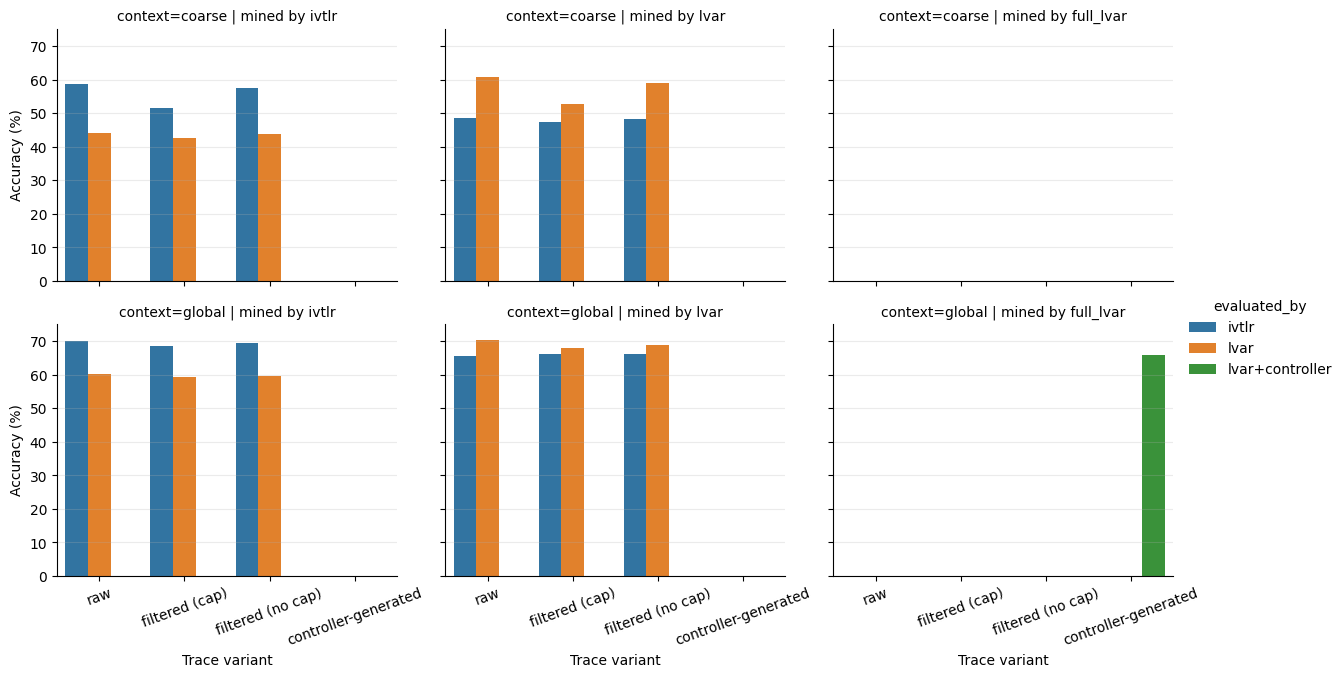

In [5]:
variant_order = ["raw", "filtered (cap)", "filtered (no cap)", "controller-generated"]
plot_df = accuracy_df.copy()
plot_df["run"] = (
    "mined=" + plot_df["mined_by"].astype(str)
    + " | eval=" + plot_df["evaluated_by"].astype(str)
    + " | " + plot_df["context"].astype(str)
)
plot_df["trace_variant_label"] = pd.Categorical(plot_df["trace_variant_label"], categories=variant_order, ordered=True)
plot_df = plot_df.sort_values(["context", "mined_by", "evaluated_by", "trace_variant_label"])

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_df,
        kind="bar",
        x="trace_variant_label",
        y="accuracy",
        hue="evaluated_by",
        col="mined_by",
        row="context",
        order=variant_order,
        height=3.2,
        aspect=1.25,
        sharey=True,
    )
    g.set_axis_labels("Trace variant", "Accuracy (%)")
    g.set_titles(row_template="context={row_name}", col_template="mined by {col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylim(0, max(75, plot_df["accuracy"].max() + 5))
    plt.show()
else:
    available_variants = [v for v in variant_order if v in plot_df["trace_variant_label"].dropna().astype(str).unique()]
    ax = plot_df.pivot_table(index="run", columns="trace_variant_label", values="accuracy", aggfunc="first")[available_variants].plot(kind="bar", figsize=(13, 6))
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy by inference setting")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [6]:
best_by_setting = (
    accuracy_df
    .sort_values("accuracy", ascending=False)
    .loc[:, ["run_type", "mined_by", "context", "evaluated_by", "trace_variant_label", "accuracy", "correct", "total", "avg_trace_actions", "avg_output_tokens"]]
    .reset_index(drop=True)
)
best_by_setting.style.format({"accuracy": "{:.2f}", "avg_trace_actions": "{:.2f}", "avg_output_tokens": "{:.2f}"}).set_caption("Inference settings ranked by accuracy")


,run_type,mined_by,context,evaluated_by,trace_variant_label,accuracy,correct,total,avg_trace_actions,avg_output_tokens
0,oracle,lvar,global,lvar,raw,70.23,1628,2318,8.79,6.02
1,oracle,ivtlr,global,ivtlr,raw,69.93,1621,2318,8.60,6.00
2,oracle,ivtlr,global,ivtlr,filtered (no cap),69.41,1609,2318,7.64,6.03
3,oracle,lvar,global,lvar,filtered (no cap),68.94,1598,2318,7.72,6.35
4,oracle,ivtlr,global,ivtlr,filtered (cap),68.68,1592,2318,6.36,6.03
5,oracle,lvar,global,lvar,filtered (cap),67.99,1576,2318,6.46,6.44
6,oracle,lvar,global,ivtlr,filtered (cap),66.26,1536,2318,6.46,6.00
7,oracle,lvar,global,ivtlr,filtered (no cap),66.05,1531,2318,7.72,6.00
8,full_lvar,full_lvar,global,lvar+controller,controller-generated,65.83,1526,2318,7.67,6.00
9,oracle,lvar,global,ivtlr,raw,65.66,1522,2318,8.79,6.00


## 2. Load The Four Test Traces

The four mined trace sets are expected to be `(lvar, global)`, `(lvar, coarse)`, `(ivtlr, global)`, and `(ivtlr, coarse)`. The loader below also reports missing summaries, because the `lvar/coarse` trace file may not have a sibling summary JSON.

In [7]:
trace_files = sorted(TRACE_ROOT.rglob("m3cot_test_traces_*_*.jsonl"))
trace_manifest_rows = []
trace_records = []
bad_trace_rows = []

for path in trace_files:
    mined_by, context = parse_trace_path(path)
    summary_path = path.with_name(path.stem + "_summary.json")
    summary = load_json(summary_path) if summary_path.exists() else {}
    rows, bad_rows = load_jsonl(path)
    bad_trace_rows.extend(bad_rows)
    trace_manifest_rows.append({
        "mined_by": mined_by,
        "context": context,
        "num_rows_loaded": len(rows),
        "summary_exists": summary_path.exists(),
        "summary_num_examples": summary.get("num_examples"),
        "summary_num_decisions": summary.get("num_decisions"),
        "summary_mean_selected_improvement": summary.get("mean_selected_improvement"),
        "initial_visual_mode": summary.get("initial_visual_mode") or (rows[0].get("initial_visual_mode") if rows else None),
        "trace_path": str(path.relative_to(ROOT)),
        "summary_path": str(summary_path.relative_to(ROOT)) if summary_path.exists() else None,
    })
    for row in rows:
        rec = dict(row)
        rec["mined_by"] = mined_by
        rec["context"] = context
        rec["trace_file"] = str(path.relative_to(ROOT))
        trace_records.append(rec)

trace_manifest = pd.DataFrame(trace_manifest_rows).sort_values(["mined_by", "context"]).reset_index(drop=True)
print(f"Trace files loaded: {len(trace_files)}")
print(f"Trace rows loaded: {len(trace_records):,}")
print(f"Bad JSONL rows: {len(bad_trace_rows):,}")
trace_manifest

Trace files loaded: 4
Trace rows loaded: 9,272
Bad JSONL rows: 0


,mined_by,context,num_rows_loaded,summary_exists,summary_num_examples,summary_num_decisions,summary_mean_selected_improvement,initial_visual_mode,trace_path,summary_path
0,ivtlr,coarse,2318,True,2318,14905,0.108189,global_mean,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_coarse.jsonl,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_coarse_summary.json
1,ivtlr,global,2318,True,2318,14712,0.067252,full_context,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_global.jsonl,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_global_summary.json
2,lvar,coarse,2318,True,2318,7751,0.093665,global_mean,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_coarse.jsonl,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_coarse_summary.json
3,lvar,global,2318,True,2318,14905,0.076528,full_context,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_global.jsonl,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_global_summary.json


In [8]:
expected_trace_keys = pd.MultiIndex.from_product([['ivtlr', 'lvar'], ['coarse', 'global']], names=['mined_by', 'context'])
actual_trace_keys = pd.MultiIndex.from_frame(trace_manifest[['mined_by', 'context']])
missing_trace_keys = expected_trace_keys.difference(actual_trace_keys)
print("Expected four trace sets present?", len(missing_trace_keys) == 0)
if len(missing_trace_keys):
    print("Missing:")
    display(missing_trace_keys.to_frame(index=False))

Expected four trace sets present? True


## Flatten Trace Metrics

`trace_examples` is one row per example per mined trace set. `trace_actions` is one row per primitive action. `trace_decisions` is one row per mined decision step. These are the core tables used below.

In [9]:
example_rows = []
action_rows = []
decision_rows = []
counterfactual_rows = []

for row in trace_records:
    mined_by = row["mined_by"]
    context = row["context"]
    example_id = row.get("example_id")
    decisions = row.get("decisions") or []
    trace = row.get("trace") or []
    steps = row.get("steps") or []
    question = row.get("question")

    reductions = [decision_reduction(d) for d in decisions]
    ce_noop_values = [d.get("ce_noop") for d in decisions if d.get("ce_noop") is not None]
    ce_selected_values = [d.get("ce_selected") for d in decisions if d.get("ce_selected") is not None]
    selected_names = [str(d.get("selected", "UNKNOWN")).upper() for d in decisions]
    decision_action_lengths = [len(d.get("actions") or []) for d in decisions]

    primitive_types = [action_type(a) for a in trace]
    primitive_no_stop = [t for t in primitive_types if t != "STOP"]
    patch_indices = [action_index(a) for a in trace if action_type(a) == "PATCH"]
    region_indices = [action_index(a) for a in trace if action_type(a) == "REGION"]

    example_rows.append({
        "mined_by": mined_by,
        "context": context,
        "example_id": example_id,
        "answer": row.get("answer"),
        "num_steps": len(steps),
        "num_decisions": len(decisions),
        "num_trace_actions_with_stop": len(trace),
        "num_trace_actions": len(primitive_no_stop),
        "num_patches": sum(1 for t in primitive_types if t == "PATCH"),
        "num_regions": sum(1 for t in primitive_types if t == "REGION"),
        "num_think": sum(1 for t in primitive_types if t == "THINK"),
        "has_stop": any(t == "STOP" for t in primitive_types),
        "num_noop_decisions": sum(1 for name, d in zip(selected_names, decisions) if name == "NO_OP" or not (d.get("actions") or [])),
        "num_positive_decisions": sum(1 for r in reductions if pd.notna(r) and r > 0),
        "total_ce_noop": finite_sum(ce_noop_values),
        "total_ce_selected": finite_sum(ce_selected_values),
        "total_ce_reduction": finite_sum(reductions),
        "mean_ce_reduction": finite_mean(reductions),
        "max_ce_reduction": max([r for r in reductions if pd.notna(r)], default=np.nan),
        "mean_decision_action_length": finite_mean(decision_action_lengths),
        "selected_decisions": selected_names,
        "primitive_action_types": primitive_types,
        "patch_indices": patch_indices,
        "region_indices": region_indices,
        "question": question,
    })

    for decision_idx, decision in enumerate(decisions):
        selected = str(decision.get("selected", "UNKNOWN")).upper()
        reduction = decision_reduction(decision)
        actions = decision.get("actions") or []
        decision_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "decision_idx": decision_idx,
            "step_idx": decision.get("step_idx"),
            "selected": selected,
            "num_actions": len(actions),
            "ce_noop": decision.get("ce_noop"),
            "ce_selected": decision.get("ce_selected"),
            "ce_reduction": reduction,
            "is_noop": selected == "NO_OP" or len(actions) == 0,
        })

    for action_idx, action in enumerate(trace):
        typ = action_type(action)
        action_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "action_idx": action_idx,
            "action_type": typ,
            "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
            "region_idx": action_index(action) if typ == "REGION" else np.nan,
        })

    for pair_idx, pair in enumerate(row.get("counterfactual_pairs") or []):
        for polarity, actions_key in [("positive", "positive_actions"), ("negative", "negative_actions")]:
            for action_pos, action in enumerate(pair.get(actions_key) or []):
                typ = action_type(action)
                counterfactual_rows.append({
                    "mined_by": mined_by,
                    "context": context,
                    "example_id": example_id,
                    "pair_idx": pair_idx,
                    "step_idx": pair.get("step_idx"),
                    "polarity": polarity,
                    "action_pos": action_pos,
                    "action_type": typ,
                    "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
                    "region_idx": action_index(action) if typ == "REGION" else np.nan,
                })

trace_examples = pd.DataFrame(example_rows)
trace_actions = pd.DataFrame(action_rows)
trace_decisions = pd.DataFrame(decision_rows)
trace_counterfactual_actions = pd.DataFrame(counterfactual_rows)

print("trace_examples", trace_examples.shape)
print("trace_actions", trace_actions.shape)
print("trace_decisions", trace_decisions.shape)
print("trace_counterfactual_actions", trace_counterfactual_actions.shape)
trace_examples.head()

trace_examples (9272, 25)
trace_actions (94489, 7)
trace_decisions (59620, 11)
trace_counterfactual_actions (169456, 10)


,mined_by,context,example_id,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,selected_decisions,primitive_action_types,patch_indices,region_indices,question
0,ivtlr,coarse,physical-commonsense-1398,B,4,4,7,6,4,1,1,True,1,3,6.867413,6.403317,0.464096,0.116024,0.270759,1.500000,"[REGION, PATCH_SEQ, PATCH_SEQ_THINK, NO_OP]","[REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]","[44, 69, 3, 29]",[13],[Question]:{What is the likely purpose of the troll statue under the bridge?}\n[Options]:\n(A).{To scare away trespassers}\n(B).{To brin...
1,ivtlr,coarse,physical-commonsense-1342,B,3,3,5,4,0,2,1,True,0,3,3.575614,2.948895,0.626719,0.208906,0.305506,1.333333,"[REGION, GLOBAL_THINK, REGION]","[REGION, GLOBAL, THINK, REGION, STOP]",[],"[5, 18]",[Question]:{What is the primary business of the truck?}\n[Options]:\n(A).{Transporting clothing}\n(B).{Selling food}\n(C).{Selling books...
2,ivtlr,coarse,physical-commonsense-1423,C,6,6,9,8,2,4,2,True,0,6,18.513145,17.026136,1.487009,0.247835,0.457760,1.333333,"[REGION, PATCH_SEQ, REGION, REGION, THINK, REGION_THINK]","[REGION, PATCH, PATCH, REGION, REGION, THINK, REGION, THINK, STOP]","[16, 14]","[21, 24, 19, 24]",[Question]:{What kind of snowboarders is the mountain in the picture suitable for?}\n[Options]:\n(A).{Beginner only}\n(B).{Not sure}\n(C...
3,ivtlr,coarse,physical-commonsense-1364,B,3,3,3,2,0,1,1,True,2,1,3.418357,3.280696,0.137661,0.045887,0.137661,0.666667,"[NO_OP, NO_OP, REGION_THINK]","[REGION, THINK, STOP]",[],[6],[Question]:{What is the purpose of the red train cart?}\n[Options]:\n(A).{Transporting cargo}\n(B).{Providing living quarters}\n(C).{Car...
4,ivtlr,coarse,physical-commonsense-1350,C,4,4,8,7,4,2,1,True,1,3,8.134082,7.519597,0.614484,0.153621,0.412117,1.750000,"[REGION, REGION, PATCH_SEQ_THINK, NO_OP]","[REGION, REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]","[69, 59, 18, 0]","[8, 2]",[Question]:{What is the possible purpose of the building in the background?}\n[Options]:\n(A).{A shopping mall}\n(B).{A bird museum}\n(C...


## Side-By-Side Trace Overview

This summarizes length, selected visual primitives, NO_OP usage, and total cross-entropy reduction for each of the four trace sets.

In [10]:
trace_overview = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        avg_steps=("num_steps", "mean"),
        avg_decisions=("num_decisions", "mean"),
        avg_trace_actions=("num_trace_actions", "mean"),
        median_trace_actions=("num_trace_actions", "median"),
        avg_patches=("num_patches", "mean"),
        avg_regions=("num_regions", "mean"),
        avg_think=("num_think", "mean"),
        avg_noop_decisions=("num_noop_decisions", "mean"),
        avg_positive_decisions=("num_positive_decisions", "mean"),
        avg_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        avg_mean_step_reduction=("mean_ce_reduction", "mean"),
    )
    .reset_index()
)
trace_overview.style.format({
    "avg_steps": "{:.2f}",
    "avg_decisions": "{:.2f}",
    "avg_trace_actions": "{:.2f}",
    "median_trace_actions": "{:.1f}",
    "avg_patches": "{:.2f}",
    "avg_regions": "{:.2f}",
    "avg_think": "{:.2f}",
    "avg_noop_decisions": "{:.2f}",
    "avg_positive_decisions": "{:.2f}",
    "avg_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "avg_mean_step_reduction": "{:.4f}",
})

,mined_by,context,examples,avg_steps,avg_decisions,avg_trace_actions,median_trace_actions,avg_patches,avg_regions,avg_think,avg_noop_decisions,avg_positive_decisions,avg_total_ce_reduction,median_total_ce_reduction,avg_mean_step_reduction
0,ivtlr,coarse,2318,6.43,6.43,10.57,10.0,7.26,2.43,0.84,1.19,5.24,0.6957,0.6258,0.1156
1,ivtlr,global,2318,6.43,6.43,7.60,7.0,4.85,2.02,0.69,2.39,4.04,0.4339,0.3943,0.0736
2,lvar,coarse,2318,6.43,6.43,10.81,11.0,7.76,2.37,0.62,1.00,5.43,0.7513,0.6668,0.1274
3,lvar,global,2318,6.43,6.43,7.79,7.0,5.29,1.79,0.62,2.34,4.09,0.4921,0.4186,0.0875


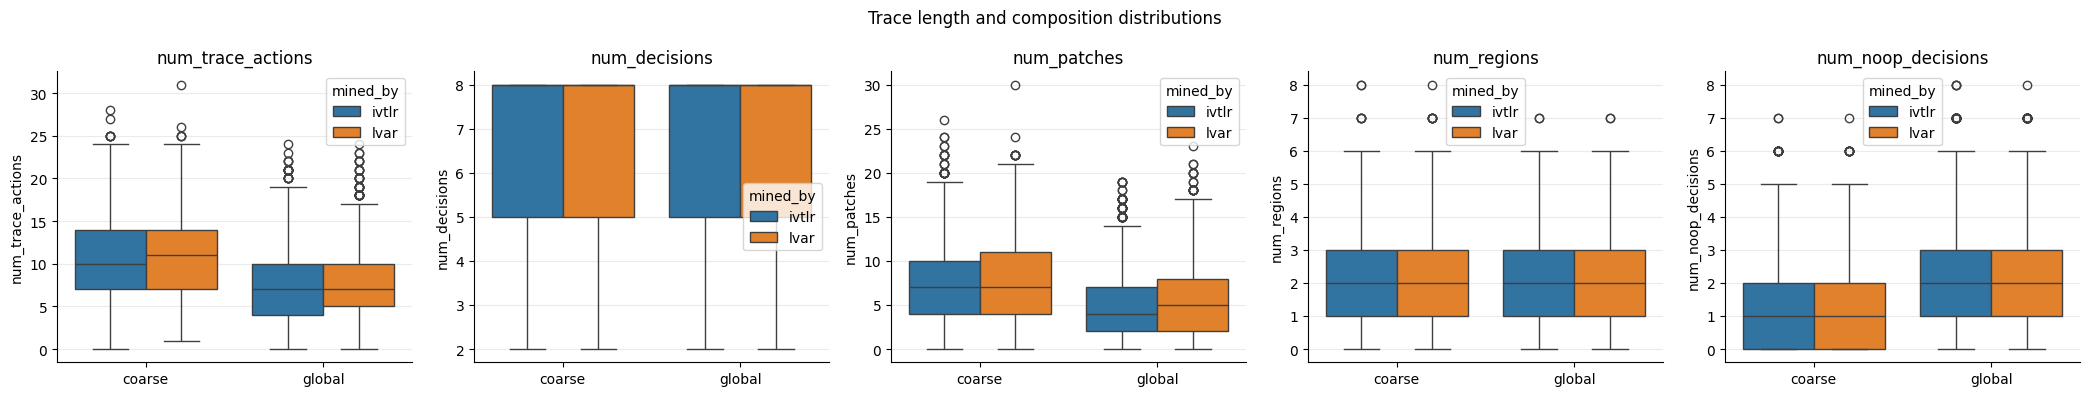

In [11]:
length_cols = ["num_trace_actions", "num_decisions", "num_patches", "num_regions", "num_noop_decisions"]
fig, axes = plt.subplots(1, len(length_cols), figsize=(4.2 * len(length_cols), 4), sharey=False)
for ax, col in zip(axes, length_cols):
    if HAS_SEABORN:
        sns.boxplot(data=trace_examples, x="context", y=col, hue="mined_by", ax=ax)
    else:
        trace_examples.boxplot(column=col, by=["mined_by", "context"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Trace length and composition distributions")
plt.tight_layout()
plt.show()

## Action And Decision Distributions

Primitive actions come from the final trace sequence. High-level decisions come from the mining controller's selected decision at each reasoning step.

In [12]:
action_dist = (
    trace_actions[trace_actions["action_type"] != "STOP"]
    .groupby(["mined_by", "context", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
action_dist["share_within_trace_set"] = action_dist["count"] / action_dist.groupby(["mined_by", "context"])["count"].transform("sum")
action_pivot = action_dist.pivot_table(index=["mined_by", "context"], columns="action_type", values="share_within_trace_set", fill_value=0)
action_pivot.style.format("{:.2%}").set_caption("Primitive action distribution by trace set")

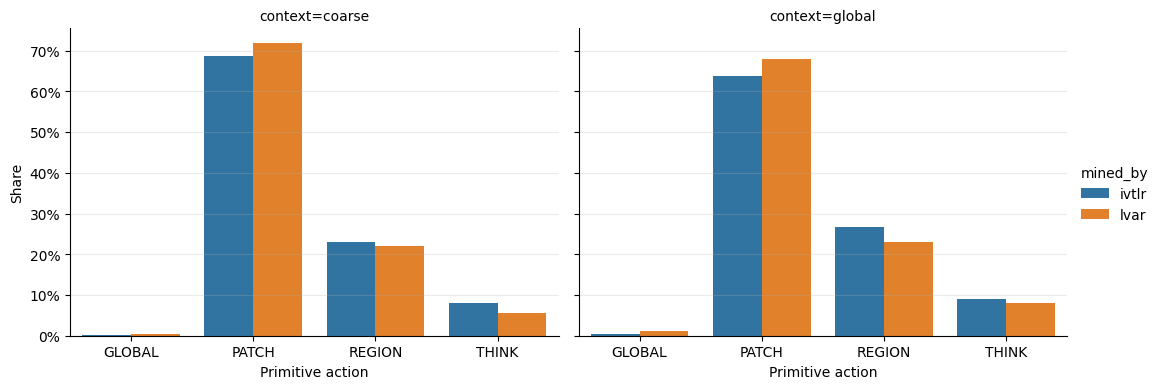

In [13]:
if HAS_SEABORN:
    g = sns.catplot(
        data=action_dist,
        kind="bar",
        x="action_type",
        y="share_within_trace_set",
        hue="mined_by",
        col="context",
        height=4,
        aspect=1.35,
    )
    g.set_axis_labels("Primitive action", "Share")
    g.set_titles("context={col_name}")
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.show()
else:
    action_pivot.plot(kind="bar", figsize=(10, 5))
    plt.ylabel("Share")
    plt.tight_layout()
    plt.show()

In [14]:
decision_dist = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .size()
    .rename("count")
    .reset_index()
)
decision_dist["share_within_trace_set"] = decision_dist["count"] / decision_dist.groupby(["mined_by", "context"])["count"].transform("sum")
decision_pivot = decision_dist.pivot_table(index=["mined_by", "context"], columns="selected", values="share_within_trace_set", fill_value=0)
decision_pivot.style.format("{:.2%}").set_caption("High-level selected decision distribution by trace set")

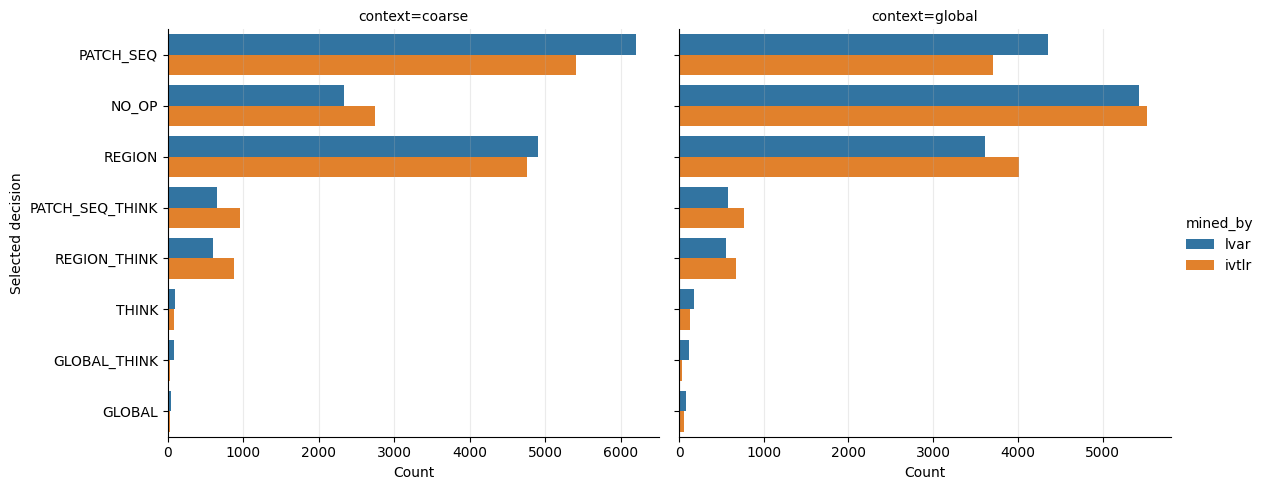

In [15]:
top_decisions = decision_dist.sort_values("count", ascending=False).head(40)
if HAS_SEABORN:
    g = sns.catplot(
        data=top_decisions,
        kind="bar",
        y="selected",
        x="count",
        hue="mined_by",
        col="context",
        height=5,
        aspect=1.2,
        sharex=False,
    )
    g.set_axis_labels("Count", "Selected decision")
    g.set_titles("context={col_name}")
    plt.show()
else:
    decision_dist.pivot_table(index="selected", columns=["mined_by", "context"], values="count", fill_value=0).plot(kind="barh", figsize=(11, 7))
    plt.tight_layout()
    plt.show()

## Selected Patches And Regions

This section shows which patch and region indices were selected most often, including heatmaps when indices form a square-ish grid. The counterfactual table compares selected positive actions against the sampled negative alternatives from mining.

In [16]:
def top_index_table(df, index_col, label, top_n=15):
    out = (
        df.dropna(subset=[index_col])
        .assign(**{index_col: lambda x: x[index_col].astype(int)})
        .groupby(["mined_by", "context", index_col])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["mined_by", "context", "count"], ascending=[True, True, False])
    )
    out["rank"] = out.groupby(["mined_by", "context"])["count"].rank(method="first", ascending=False).astype(int)
    return out[out["rank"] <= top_n].rename(columns={index_col: label})

selected_patch_top = top_index_table(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "patch_idx")
selected_region_top = top_index_table(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "region_idx")

print("Top selected patches")
display(selected_patch_top)
print("Top selected regions")
display(selected_region_top)

Top selected patches


,mined_by,context,patch_idx,count,rank
99,ivtlr,coarse,99,416,1
89,ivtlr,coarse,89,337,2
91,ivtlr,coarse,91,309,3
90,ivtlr,coarse,90,288,4
81,ivtlr,coarse,81,271,5
92,ivtlr,coarse,92,265,6
96,ivtlr,coarse,96,248,7
82,ivtlr,coarse,82,244,8
97,ivtlr,coarse,97,244,9
94,ivtlr,coarse,94,241,10


Top selected regions


,mined_by,context,region_idx,count,rank
20,ivtlr,coarse,20,455,1
24,ivtlr,coarse,24,394,2
21,ivtlr,coarse,21,331,3
22,ivtlr,coarse,22,289,4
15,ivtlr,coarse,15,286,5
5,ivtlr,coarse,5,251,6
23,ivtlr,coarse,23,242,7
16,ivtlr,coarse,16,231,8
1,ivtlr,coarse,1,225,9
11,ivtlr,coarse,11,225,10


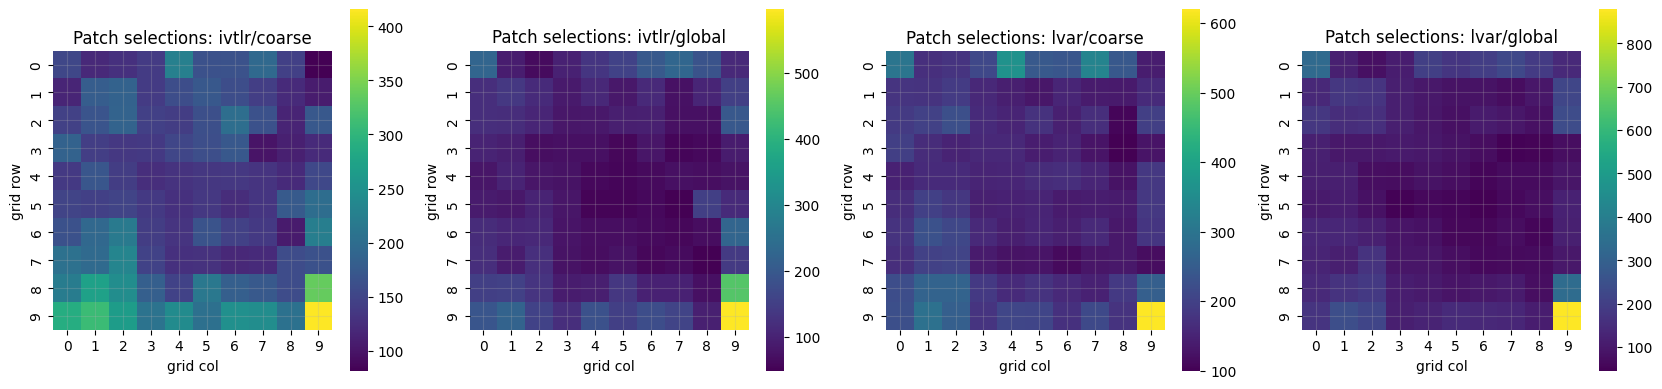

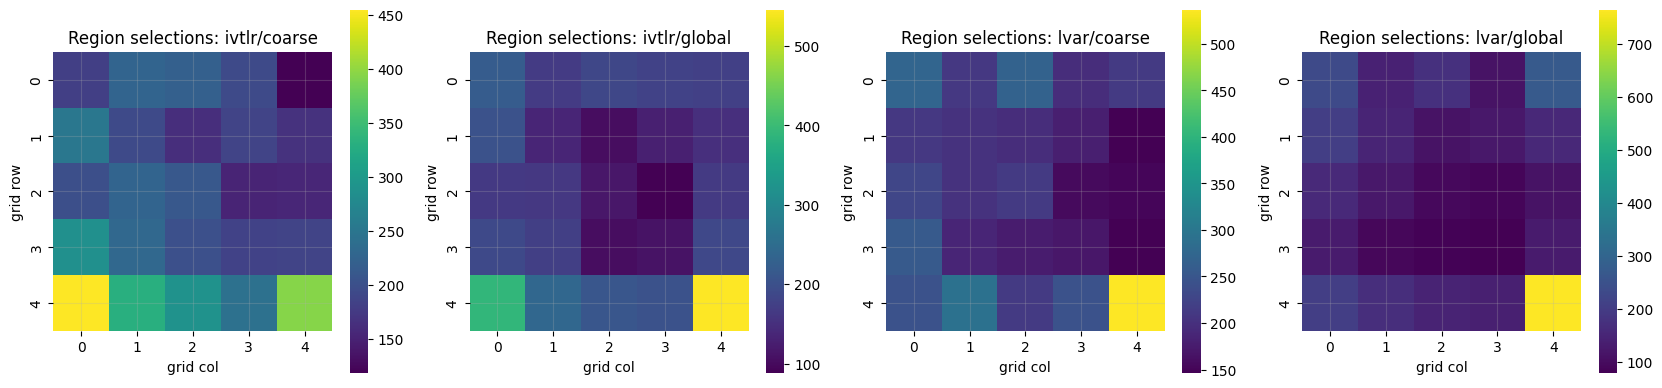

In [17]:
def plot_index_heatmaps(df, index_col, title_prefix):
    usable = df.dropna(subset=[index_col]).copy()
    if usable.empty:
        print(f"No indices available for {index_col}")
        return
    usable[index_col] = usable[index_col].astype(int)
    groups = list(usable.groupby(["mined_by", "context"]))
    fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 4), squeeze=False)
    for ax, ((mined_by, context), group) in zip(axes.flat, groups):
        n = infer_grid_size(group[index_col].tolist())
        grid = np.zeros((n, n), dtype=float)
        counts = group[index_col].value_counts()
        for idx, count in counts.items():
            grid[int(idx) // n, int(idx) % n] = count
        if HAS_SEABORN:
            sns.heatmap(grid, ax=ax, cmap="viridis", cbar=True, square=True)
        else:
            im = ax.imshow(grid, cmap="viridis")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"{title_prefix}: {mined_by}/{context}")
        ax.set_xlabel("grid col")
        ax.set_ylabel("grid row")
    plt.tight_layout()
    plt.show()

plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "Patch selections")
plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "Region selections")

In [18]:
cf_summary = (
    trace_counterfactual_actions
    .groupby(["mined_by", "context", "polarity", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
cf_summary["share"] = cf_summary["count"] / cf_summary.groupby(["mined_by", "context", "polarity"])["count"].transform("sum")
cf_summary.pivot_table(index=["mined_by", "context", "polarity"], columns="action_type", values="share", fill_value=0).style.format("{:.2%}").set_caption("Counterfactual positive vs negative action distribution")

## Cross-Entropy Reduction

`total_ce_reduction` is the sum over mined decisions of `ce_noop - ce_selected` (or the stored `improvement`). This captures the total reduction in target continuation cross entropy attributable to the selected trace decisions for an example.

In [19]:
ce_summary = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_reduction=("total_ce_reduction", "mean"),
        median_total_reduction=("total_ce_reduction", "median"),
        std_total_reduction=("total_ce_reduction", "std"),
        p10_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.10)),
        p90_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.90)),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_positive_decisions=("num_positive_decisions", "mean"),
    )
    .reset_index()
)
ce_summary.style.format({c: "{:.4f}" for c in ce_summary.columns if c not in ["mined_by", "context", "examples"]})

,mined_by,context,examples,mean_total_reduction,median_total_reduction,std_total_reduction,p10_total_reduction,p90_total_reduction,mean_step_reduction,mean_positive_decisions
0,ivtlr,coarse,2318,0.6957,0.6258,0.3704,0.3038,1.1822,0.1156,5.2433
1,ivtlr,global,2318,0.4339,0.3943,0.2596,0.1488,0.7740,0.0736,4.0444
2,lvar,coarse,2318,0.7513,0.6668,0.4132,0.3127,1.2973,0.1274,5.4254
3,lvar,global,2318,0.4921,0.4186,0.3071,0.1719,0.9108,0.0875,4.0867


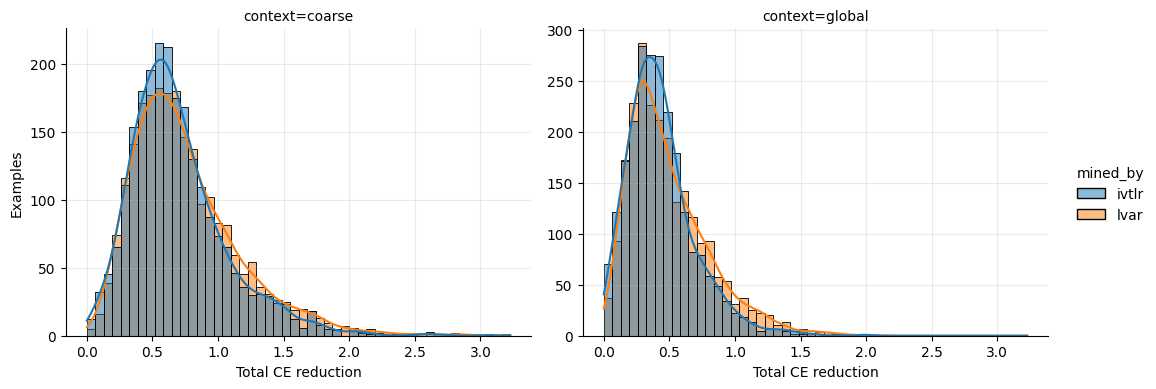

In [20]:
if HAS_SEABORN:
    g = sns.displot(
        data=trace_examples,
        x="total_ce_reduction",
        hue="mined_by",
        col="context",
        kind="hist",
        bins=50,
        kde=True,
        height=4,
        aspect=1.35,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set_axis_labels("Total CE reduction", "Examples")
    g.set_titles("context={col_name}")
    plt.show()
else:
    for (mined_by, context), group in trace_examples.groupby(["mined_by", "context"]):
        plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, label=f"{mined_by}/{context}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Examples")
    plt.legend()
    plt.show()

In [21]:
step_reduction_summary = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .agg(
        decisions=("ce_reduction", "size"),
        mean_reduction=("ce_reduction", "mean"),
        median_reduction=("ce_reduction", "median"),
        positive_rate=("ce_reduction", lambda s: (s > 0).mean()),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "mean_reduction"], ascending=[True, True, False])
)
step_reduction_summary.style.format({"mean_reduction": "{:.4f}", "median_reduction": "{:.4f}", "positive_rate": "{:.2%}"}).set_caption("CE reduction by selected high-level decision")

,mined_by,context,selected,decisions,mean_reduction,median_reduction,positive_rate
7,ivtlr,coarse,THINK,87,0.1988,0.1434,100.00%
4,ivtlr,coarse,PATCH_SEQ_THINK,962,0.1607,0.1095,100.00%
6,ivtlr,coarse,REGION_THINK,872,0.1519,0.1064,100.00%
1,ivtlr,coarse,GLOBAL_THINK,36,0.1464,0.1125,100.00%
3,ivtlr,coarse,PATCH_SEQ,5399,0.1280,0.1009,100.00%
5,ivtlr,coarse,REGION,4763,0.1278,0.1029,100.00%
0,ivtlr,coarse,GLOBAL,35,0.0913,0.0859,100.00%
2,ivtlr,coarse,NO_OP,2751,0.0000,0.0000,0.00%
9,ivtlr,global,GLOBAL_THINK,40,0.1389,0.1099,100.00%
15,ivtlr,global,THINK,128,0.1361,0.0763,100.00%


## 3. Correct vs Incorrect Inference Outcomes

This loads every oracle prediction JSONL plus the full LVAR model + controller predictions. Oracle outcomes are joined back to mined trace features by `(mined_by, context, example_id)`; the full run remains in the shared prediction table but naturally has no oracle-mining CE features.


In [22]:
prediction_rows = []
bad_prediction_rows = []


def append_prediction_rows(rows, metadata, output_path):
    for row in rows:
        prediction_rows.append({
            **metadata,
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "raw_answer": row.get("raw_answer"),
            "generated_text": row.get("generated_text"),
            "decoded_answer": row.get("decoded_answer"),
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "num_inference_trace_actions": row.get("num_trace_actions") or row.get("num_steps") or row.get("num_controller_actions"),
            "num_output_tokens": row.get("num_output_tokens"),
            "controller_actions": [str(step.get("action", "UNKNOWN")).upper() for step in (row.get("trace") or [])],
            "kept_primitives": (row.get("transform") or {}).get("kept_primitives"),
            "cap_applied": (row.get("transform") or {}).get("cap_applied"),
            "prediction_path": str(output_path.relative_to(ROOT)),
        })


for summary_path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(summary_path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(summary_path)
    trace_variant = summary.get("trace_variant") or variant_from_path
    output_path = Path(summary.get("output_path", ""))
    if not output_path.is_absolute():
        output_path = ROOT / output_path
    if not output_path.exists():
        print(f"Missing prediction file: {output_path}")
        continue
    rows, bad_rows = load_jsonl(output_path)
    bad_prediction_rows.extend(bad_rows)
    append_prediction_rows(rows, {
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": summary.get("context"),
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
    }, output_path)

full_lvar_predictions_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions.jsonl"
if full_lvar_predictions_path.exists():
    rows, bad_rows = load_jsonl(full_lvar_predictions_path)
    bad_prediction_rows.extend(bad_rows)
    full_summary = load_json(full_lvar_summary_path) if full_lvar_summary_path.exists() else {}
    append_prediction_rows(rows, {
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if full_summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
    }, full_lvar_predictions_path)

predictions = pd.DataFrame(prediction_rows)
print("prediction rows", predictions.shape)
print("bad prediction rows", len(bad_prediction_rows))
predictions.head()


prediction rows (57950, 20)
bad prediction rows 0


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,controller_actions,kept_primitives,cap_applied,prediction_path
0,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1398,False,b,B,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,7,6,"[REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]",7.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
1,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1342,True,b,B,"Therefore, the answer is B","Therefore, the answer is B",commonsense,physical-commonsense,5,6,"[REGION, GLOBAL, THINK, REGION, STOP]",5.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
2,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1423,True,c,C,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,"[REGION, PATCH, PATCH, REGION, REGION, THINK, STOP]",7.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
3,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1364,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,3,6,"[REGION, THINK, STOP]",3.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
4,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1350,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,8,6,"[REGION, REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]",8.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...


In [23]:
join_cols = ["mined_by", "context", "example_id"]
trace_features = trace_examples.drop(columns=["selected_decisions", "primitive_action_types", "patch_indices", "region_indices"], errors="ignore")
correctness_traces = predictions.merge(trace_features, on=join_cols, how="left", suffixes=("_pred", "_trace"))

missing_trace_join = correctness_traces["total_ce_reduction"].isna().sum()
print(f"Joined prediction rows: {len(correctness_traces):,}")
print(f"Rows missing trace features after join: {missing_trace_join:,}")
correctness_traces.head()

Joined prediction rows: 57,950
Rows missing trace features after join: 2,318


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,controller_actions,kept_primitives,cap_applied,prediction_path,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,question
0,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1398,False,b,B,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,7,6,"[REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]",7.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,4.0,4.0,7.0,6.0,4.0,1.0,1.0,True,1.0,3.0,6.867413,6.403317,0.464096,0.116024,0.270759,1.500000,[Question]:{What is the likely purpose of the troll statue under the bridge?}\n[Options]:\n(A).{To scare away trespassers}\n(B).{To brin...
1,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1342,True,b,B,"Therefore, the answer is B","Therefore, the answer is B",commonsense,physical-commonsense,5,6,"[REGION, GLOBAL, THINK, REGION, STOP]",5.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,3.0,3.0,5.0,4.0,0.0,2.0,1.0,True,0.0,3.0,3.575614,2.948895,0.626719,0.208906,0.305506,1.333333,[Question]:{What is the primary business of the truck?}\n[Options]:\n(A).{Transporting clothing}\n(B).{Selling food}\n(C).{Selling books...
2,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1423,True,c,C,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,"[REGION, PATCH, PATCH, REGION, REGION, THINK, STOP]",7.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,C,6.0,6.0,9.0,8.0,2.0,4.0,2.0,True,0.0,6.0,18.513145,17.026136,1.487009,0.247835,0.457760,1.333333,[Question]:{What kind of snowboarders is the mountain in the picture suitable for?}\n[Options]:\n(A).{Beginner only}\n(B).{Not sure}\n(C...
3,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1364,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,3,6,"[REGION, THINK, STOP]",3.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,3.0,3.0,3.0,2.0,0.0,1.0,1.0,True,2.0,1.0,3.418357,3.280696,0.137661,0.045887,0.137661,0.666667,[Question]:{What is the purpose of the red train cart?}\n[Options]:\n(A).{Transporting cargo}\n(B).{Providing living quarters}\n(C).{Car...
4,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1350,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,8,6,"[REGION, REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]",8.0,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,C,4.0,4.0,8.0,7.0,4.0,2.0,1.0,True,1.0,3.0,8.134082,7.519597,0.614484,0.153621,0.412117,1.750000,[Question]:{What is the possible purpose of the building in the background?}\n[Options]:\n(A).{A shopping mall}\n(B).{A bird museum}\n(C...


In [24]:
correctness_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "evaluated_by", "trace_variant_label", "correct"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
        mean_patches=("num_patches", "mean"),
        mean_regions=("num_regions", "mean"),
        mean_noop_decisions=("num_noop_decisions", "mean"),
        mean_inference_trace_actions=("num_inference_trace_actions", "mean"),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "evaluated_by", "trace_variant_label", "correct"])
)
correctness_summary.style.format({
    "mean_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "mean_step_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
    "mean_patches": "{:.2f}",
    "mean_regions": "{:.2f}",
    "mean_noop_decisions": "{:.2f}",
    "mean_inference_trace_actions": "{:.2f}",
}).set_caption("Mined trace statistics split by correct vs incorrect inference outcomes")

,mined_by,context,evaluated_by,trace_variant_label,correct,examples,mean_total_ce_reduction,median_total_ce_reduction,mean_step_reduction,mean_trace_actions,mean_patches,mean_regions,mean_noop_decisions,mean_inference_trace_actions
0,full_lvar,global,lvar+controller,controller-generated,False,792,nan,nan,nan,nan,nan,nan,nan,7.64
1,full_lvar,global,lvar+controller,controller-generated,True,1526,nan,nan,nan,nan,nan,nan,nan,7.68
2,ivtlr,coarse,ivtlr,filtered (cap),False,1125,0.7161,0.6561,0.1179,11.32,7.81,2.54,1.02,7.83
3,ivtlr,coarse,ivtlr,filtered (cap),True,1193,0.6764,0.5988,0.1135,9.86,6.74,2.33,1.34,7.39
4,ivtlr,coarse,ivtlr,filtered (no cap),False,985,0.6745,0.6252,0.1139,10.90,7.49,2.51,1.09,11.06
5,ivtlr,coarse,ivtlr,filtered (no cap),True,1333,0.7113,0.6261,0.1169,10.32,7.09,2.38,1.26,10.71
6,ivtlr,coarse,ivtlr,raw,False,958,0.6748,0.6232,0.1144,10.83,7.41,2.50,1.10,11.83
7,ivtlr,coarse,ivtlr,raw,True,1360,0.7104,0.6265,0.1165,10.38,7.15,2.38,1.25,11.38
8,ivtlr,coarse,lvar,filtered (cap),False,1333,0.6978,0.6416,0.1161,10.92,7.57,2.47,1.10,7.69
9,ivtlr,coarse,lvar,filtered (cap),True,985,0.6927,0.6057,0.1149,10.08,6.84,2.37,1.30,7.49


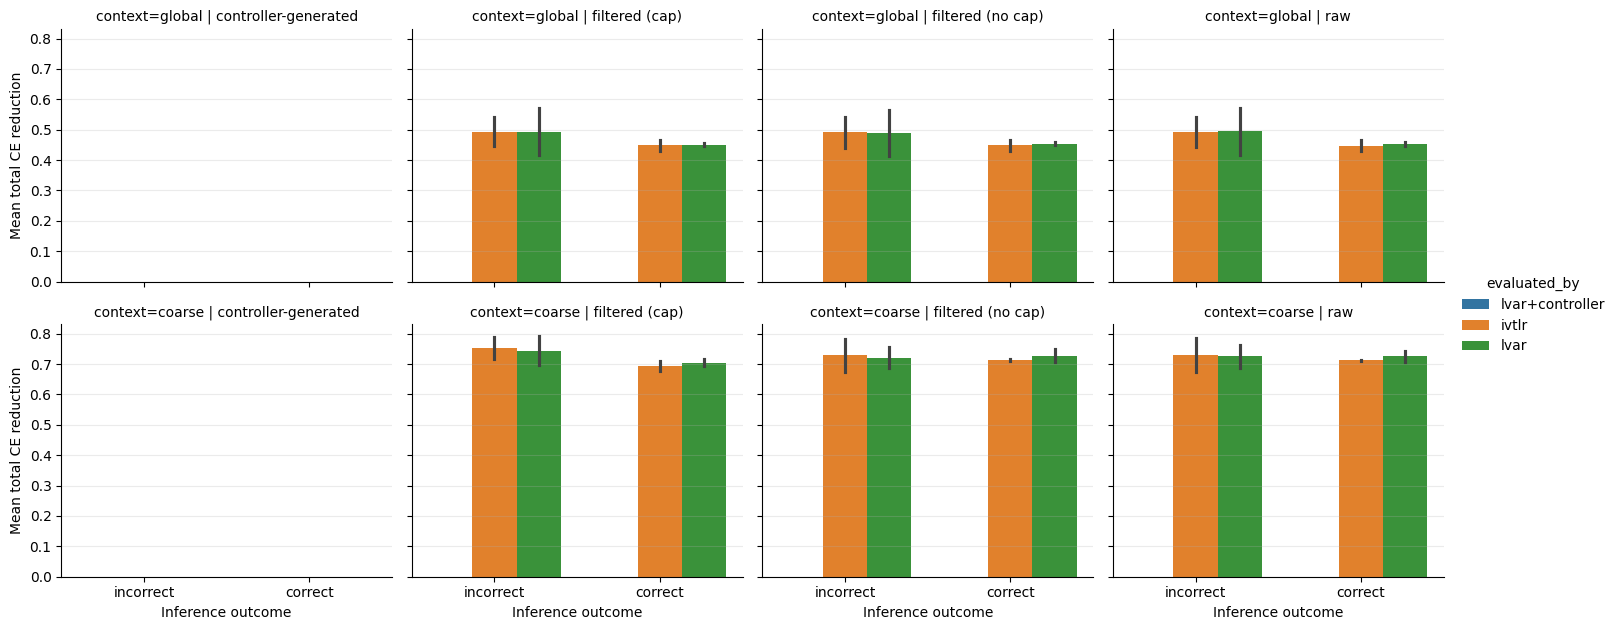

In [25]:
plot_correctness = correctness_summary.copy()
plot_correctness["outcome"] = np.where(plot_correctness["correct"], "correct", "incorrect")
plot_correctness["setting"] = (
    "mined=" + plot_correctness["mined_by"].astype(str)
    + " | eval=" + plot_correctness["evaluated_by"].astype(str)
    + " | " + plot_correctness["context"].astype(str)
    + " | " + plot_correctness["trace_variant_label"].astype(str)
)

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_correctness,
        kind="bar",
        x="outcome",
        y="mean_total_ce_reduction",
        hue="evaluated_by",
        col="trace_variant_label",
        row="context",
        height=3.2,
        aspect=1.15,
        sharey=True,
    )
    g.set_axis_labels("Inference outcome", "Mean total CE reduction")
    g.set_titles(row_template="context={row_name}", col_template="{col_name}")
    plt.show()
else:
    correctness_summary.pivot_table(index=["context", "trace_variant_label", "correct"], columns=["mined_by", "evaluated_by"], values="mean_total_ce_reduction").plot(kind="bar", figsize=(13, 6))
    plt.ylabel("Mean total CE reduction")
    plt.tight_layout()
    plt.show()

Selected rows: 2,318
correct
True     1621
False     697
Name: count, dtype: int64


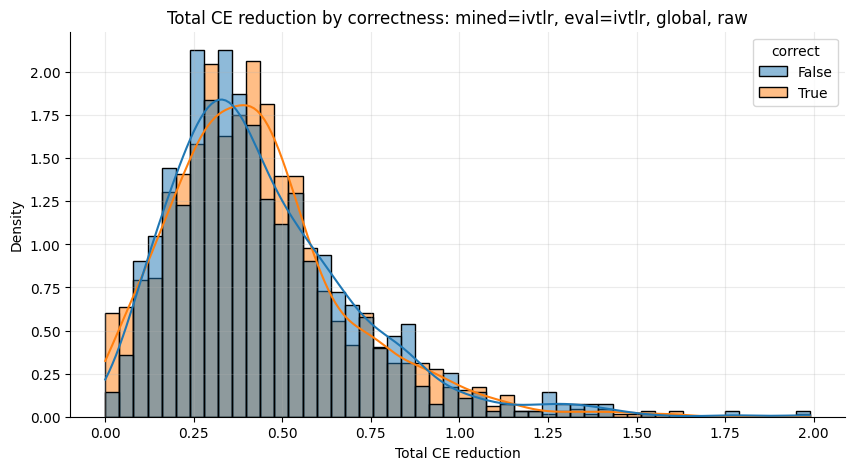

In [26]:
# Pick one setting for a detailed correct-vs-incorrect histogram. Change these selectors as needed.
SELECT_MINED_BY = "ivtlr"
SELECT_CONTEXT = "global"
SELECT_EVALUATED_BY = "ivtlr"
SELECT_TRACE_VARIANT = "raw"

selected_run = correctness_traces[
    (correctness_traces["mined_by"] == SELECT_MINED_BY)
    & (correctness_traces["context"] == SELECT_CONTEXT)
    & (correctness_traces["evaluated_by"] == SELECT_EVALUATED_BY)
    & (correctness_traces["trace_variant"] == SELECT_TRACE_VARIANT)
].copy()

print(f"Selected rows: {len(selected_run):,}")
print(selected_run["correct"].value_counts(dropna=False))

if not selected_run.empty:
    if HAS_SEABORN:
        sns.histplot(data=selected_run, x="total_ce_reduction", hue="correct", bins=50, kde=True, stat="density", common_norm=False)
    else:
        for correct, group in selected_run.groupby("correct"):
            plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, density=True, label=f"correct={correct}")
        plt.legend()
    plt.title(f"Total CE reduction by correctness: mined={SELECT_MINED_BY}, eval={SELECT_EVALUATED_BY}, {SELECT_CONTEXT}, {SELECT_TRACE_VARIANT}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Density")
    plt.show()

## 4. Decoding Entropy Analysis

Each entropy sidecar contains one row per sample. `answer_option_entropy` is measured at the decoding step where the model emits its selected A/B/C/D answer; `decoded_token_entropy_mean`, `median`, and `max` aggregate full-vocabulary entropy across the generated answer trace. The loaders below combine oracle runs and the full LVAR model + controller run with the same placeholder metadata used above.


In [27]:
entropy_rows = []


def resolve_from_root(path_value):
    path = Path(path_value)
    return path if path.is_absolute() else ROOT / path


def append_entropy_rows(rows, metadata, entropy_path):
    for row in rows:
        entropy_rows.append({
            **metadata,
            "run_label": (
                f"{metadata['mined_by']} | {metadata['context']} | "
                f"{metadata['evaluated_by']} | {metadata['trace_variant_label']}"
            ),
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "decoded_answer": row.get("decoded_answer"),
            "num_output_tokens": row.get("num_output_tokens"),
            "answer_option_entropy": row.get("answer_option_entropy"),
            "decoded_token_entropy_mean": row.get("decoded_token_entropy_mean"),
            "decoded_token_entropy_median": row.get("decoded_token_entropy_median"),
            "decoded_token_entropy_max": row.get("decoded_token_entropy_max"),
            "controller_action_entropy_mean": row.get("controller_action_entropy_mean"),
            "controller_action_entropy_median": row.get("controller_action_entropy_median"),
            "controller_action_entropy_max": row.get("controller_action_entropy_max"),
            "controller_region_entropy_mean": row.get("controller_region_entropy_mean"),
            "controller_region_entropy_median": row.get("controller_region_entropy_median"),
            "controller_region_entropy_max": row.get("controller_region_entropy_max"),
            "controller_patch_entropy_mean": row.get("controller_patch_entropy_mean"),
            "controller_patch_entropy_median": row.get("controller_patch_entropy_median"),
            "controller_patch_entropy_max": row.get("controller_patch_entropy_max"),
            "controller_entropy_mean": row.get("controller_entropy_mean"),
            "controller_entropy_median": row.get("controller_entropy_median"),
            "controller_entropy_max": row.get("controller_entropy_max"),
            "controller_action_entropies": row.get("controller_action_entropies"),
            "controller_region_entropies": row.get("controller_region_entropies"),
            "controller_patch_entropies": row.get("controller_patch_entropies"),
            "controller_entropies": row.get("controller_entropies"),
            "answer_option_selected_option": row.get("answer_option_selected_option"),
            "answer_option_decoded_token_index": row.get("answer_option_decoded_token_index"),
            "answer_option_probabilities": row.get("answer_option_probabilities"),
            "decoded_token_entropies": row.get("decoded_token_entropies"),
            "entropy_path": str(entropy_path.relative_to(ROOT)),
        })


for summary_path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(summary_path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(summary_path)
    trace_variant = summary.get("trace_variant") or variant_from_path
    entropy_value = summary.get("entropy_tracking_path")
    if entropy_value:
        entropy_path = resolve_from_root(entropy_value)
    else:
        prediction_path = resolve_from_root(summary.get("output_path", ""))
        entropy_path = prediction_path.with_name(f"{prediction_path.stem}_entropy_tracking.json")
    if not entropy_path.exists():
        print(f"Missing entropy sidecar: {entropy_path}")
        continue
    append_entropy_rows(load_json(entropy_path), {
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": summary.get("context"),
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
    }, entropy_path)

full_lvar_entropy_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions_entropy_tracking.json"
if full_lvar_entropy_path.exists():
    full_summary = load_json(full_lvar_summary_path) if full_lvar_summary_path.exists() else {}
    append_entropy_rows(load_json(full_lvar_entropy_path), {
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if full_summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
    }, full_lvar_entropy_path)
else:
    print(f"Full LVAR entropy sidecar not found: {full_lvar_entropy_path}")

entropy_df = pd.DataFrame(entropy_rows)
entropy_metric_cols = [
    "answer_option_entropy",
    "decoded_token_entropy_mean",
    "decoded_token_entropy_median",
    "decoded_token_entropy_max",
    "controller_action_entropy_mean",
    "controller_region_entropy_mean",
    "controller_patch_entropy_mean",
    "controller_entropy_mean",
]
for col in entropy_metric_cols:
    entropy_df[col] = pd.to_numeric(entropy_df[col], errors="coerce")

print(f"Entropy rows loaded: {len(entropy_df):,}")
print(f"Runs loaded: {entropy_df['run_label'].nunique():,}")
print("Metric coverage:")
display(entropy_df[entropy_metric_cols].notna().mean().rename("fraction_present").to_frame().style.format("{:.2%}"))
entropy_df.head()


Entropy rows loaded: 57,950
Runs loaded: 25
Metric coverage:


,fraction_present
answer_option_entropy,97.83%
decoded_token_entropy_mean,99.99%
decoded_token_entropy_median,99.99%
decoded_token_entropy_max,99.99%
controller_action_entropy_mean,4.00%
controller_region_entropy_mean,4.00%
controller_patch_entropy_mean,4.00%
controller_entropy_mean,4.00%


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,run_label,example_id,correct,gold_answer,decoded_answer,num_output_tokens,answer_option_entropy,decoded_token_entropy_mean,decoded_token_entropy_median,decoded_token_entropy_max,controller_action_entropy_mean,controller_action_entropy_median,controller_action_entropy_max,controller_region_entropy_mean,controller_region_entropy_median,controller_region_entropy_max,controller_patch_entropy_mean,controller_patch_entropy_median,controller_patch_entropy_max,controller_entropy_mean,controller_entropy_median,controller_entropy_max,controller_action_entropies,controller_region_entropies,controller_patch_entropies,controller_entropies,answer_option_selected_option,answer_option_decoded_token_index,answer_option_probabilities,decoded_token_entropies,entropy_path
0,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),ivtlr | coarse | ivtlr | filtered (cap),physical-commonsense-1398,False,b,"Therefore, the answer is D",6,1.303769,0.074468,0.000061,0.444440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,D,5.0,"{'A': 0.19643403589725494, 'B': 0.18134695291519165, 'C': 0.18567170202732086, 'D': 0.43654733896255493}","[0.002235004911199212, 2.5700517198856687e-06, 4.1779094317462295e-05, 8.009400335140526e-05, 6.611238859477453e-06, 0.4444403648376465]",outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
1,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),ivtlr | coarse | ivtlr | filtered (cap),physical-commonsense-1342,True,b,"Therefore, the answer is B",6,1.270171,0.006931,0.000020,0.039291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,B,5.0,"{'A': 0.17586323618888855, 'B': 0.4734894335269928, 'C': 0.17523093521595, 'D': 0.17541633546352386}","[0.002248428063467145, 3.928990281565348e-06, 1.705253089312464e-05, 2.3266187781700864e-05, 1.361656359222252e-06, 0.03929077461361885]",outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
2,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),ivtlr | coarse | ivtlr | filtered (cap),physical-commonsense-1423,True,c,"Therefore, the answer is C",6,1.343803,0.112703,0.000044,0.675783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,C,5.0,"{'A': 0.1891319453716278, 'B': 0.1869611293077469, 'C': 0.3715525269508362, 'D': 0.25235438346862793}","[0.0003426726325415075, 6.926532660145313e-05, 3.775593540922273e-06, 1.8041995645035058e-05, 1.949761099240277e-06, 0.6757829189300537]",outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
3,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),ivtlr | coarse | ivtlr | filtered (cap),physical-commonsense-1364,False,b,"Therefore, the answer is C",6,1.308726,0.074821,0.000031,0.447762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,C,5.0,"{'A': 0.18172912299633026, 'B': 0.20525310933589935, 'C': 0.4298703074455261, 'D': 0.18314753472805023}","[0.0010915815364569426, 8.531986168236472e-06, 4.000835360784549e-06, 5.4223317420110106e-05, 5.4406259550887626e-06, 0.44776177406311035]",outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
4,oracle,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),ivtlr | coarse | ivtlr | filtered (cap),physical-commonsense-1350,False,c,"Therefore, the answer is D",6,1.268412,0.000770,0.000052,0.003277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,D,5.0,"{'A': 0.17490315437316895, 'B': 0.1749403327703476, 'C': 0.17490054666996002, 'D': 0.47525596618652344}","[0.0012309567537158728, 5.344179953681305e-06, 6.052265962352976e-05, 4.2792125896085054e-05, 2.495125045243185e-06, 0.003276882926002145]",outputs/inference/test_or

In [28]:
entropy_summary = (
    entropy_df
    .groupby(["run_type", "mined_by", "context", "evaluated_by", "trace_variant_label", "correct"], dropna=False)
    .agg(
        samples=("example_id", "size"),
        option_entropy_available=("answer_option_entropy", "count"),
        mean_option_entropy=("answer_option_entropy", "mean"),
        median_option_entropy=("answer_option_entropy", "median"),
        mean_answer_entropy=("decoded_token_entropy_mean", "mean"),
        median_answer_entropy=("decoded_token_entropy_mean", "median"),
        mean_peak_token_entropy=("decoded_token_entropy_max", "mean"),
        mean_controller_action_entropy=("controller_action_entropy_mean", "mean"),
        mean_controller_region_entropy=("controller_region_entropy_mean", "mean"),
        mean_controller_patch_entropy=("controller_patch_entropy_mean", "mean"),
        mean_controller_entropy=("controller_entropy_mean", "mean"),
        mean_output_tokens=("num_output_tokens", "mean"),
    )
    .reset_index()
)
entropy_summary["option_entropy_coverage"] = entropy_summary["option_entropy_available"] / entropy_summary["samples"]
entropy_summary.style.format({
    "option_entropy_coverage": "{:.2%}",
    "mean_option_entropy": "{:.4f}",
    "median_option_entropy": "{:.4f}",
    "mean_answer_entropy": "{:.4f}",
    "median_answer_entropy": "{:.4f}",
    "mean_peak_token_entropy": "{:.4f}",
    "mean_controller_action_entropy": "{:.4f}",
    "mean_controller_region_entropy": "{:.4f}",
    "mean_controller_patch_entropy": "{:.4f}",
    "mean_controller_entropy": "{:.4f}",
    "mean_output_tokens": "{:.2f}",
}).set_caption("Entropy metrics split by correctness for every run")


,run_type,mined_by,context,evaluated_by,trace_variant_label,correct,samples,option_entropy_available,mean_option_entropy,median_option_entropy,mean_answer_entropy,median_answer_entropy,mean_peak_token_entropy,mean_controller_action_entropy,mean_controller_region_entropy,mean_controller_patch_entropy,mean_controller_entropy,mean_output_tokens,option_entropy_coverage
0,full_lvar,full_lvar,global,lvar+controller,controller-generated,False,792,777,1.3261,1.3369,0.1066,0.1142,0.6289,0.6870,2.5042,3.5790,0.6870,6.00,98.11%
1,full_lvar,full_lvar,global,lvar+controller,controller-generated,True,1526,1505,1.2893,1.2690,0.0396,0.0058,0.2323,0.6778,2.5386,3.6234,0.6778,6.00,98.62%
2,oracle,ivtlr,coarse,ivtlr,filtered (cap),False,1125,1109,1.3404,1.3550,0.1418,0.1457,0.7908,nan,nan,nan,nan,6.08,98.58%
3,oracle,ivtlr,coarse,ivtlr,filtered (cap),True,1193,1173,1.3173,1.3176,0.0980,0.0923,0.5440,nan,nan,nan,nan,6.04,98.32%
4,oracle,ivtlr,coarse,ivtlr,filtered (no cap),False,985,969,1.3413,1.3550,0.1368,0.1432,0.7860,nan,nan,nan,nan,6.00,98.38%
5,oracle,ivtlr,coarse,ivtlr,filtered (no cap),True,1333,1313,1.3167,1.3167,0.0939,0.0904,0.5296,nan,nan,nan,nan,6.00,98.50%
6,oracle,ivtlr,coarse,ivtlr,raw,False,958,944,1.3414,1.3553,0.1347,0.1428,0.7853,nan,nan,nan,nan,6.00,98.54%
7,oracle,ivtlr,coarse,ivtlr,raw,True,1360,1341,1.3157,1.3140,0.0905,0.0864,0.5165,nan,nan,nan,nan,6.00,98.60%
8,oracle,ivtlr,coarse,lvar,filtered (cap),False,1333,1264,1.3180,1.3179,0.2595,0.1406,1.1467,nan,nan,nan,nan,8.86,94.82%
9,oracle,ivtlr,coarse,lvar,filtered (cap),True,985,968,1.3017,1.2790,0.1790,0.0841,0.8247,nan,nan,nan,nan,7.23,98.27%


### Correct vs Incorrect Entropy Histograms

The default selection is the full LVAR pipeline. Change the four selectors to inspect an oracle run. The left panel shows uncertainty among A/B/C/D at answer selection; the right panel shows mean full-vocabulary entropy across all decoded tokens.


Selected entropy rows: 2,318


answer_option_entropy                               decoded_token_entropy_mean                               decoded_token_entropy_median                                \
                        count      mean    median       std                      count      mean    median       std                        count      mean    median       std   
correct                                                                                                                                                                           
False                     777  1.326114  1.336892  0.040831                        792  0.106581  0.114241  0.072292                          792  0.000081  0.000021  0.000802   
True                     1505  1.289298  1.269041  0.033272                       1526  0.039567  0.005790  0.057446                         1526  0.000059  0.000022  0.000580   

        decoded_token_entropy_max                               controller_action_entropy_mean                               controller_region_entropy_mean                      \
                            count      mean    median       std                          count      mean    median       std                          count      mean    median   
correct                                                                                                                                                                           
False                         792  0.628861  0.679850  0.430632                            792  0.686957  0.690705  0.110991                            792  2.504245  2.515819   
True                         1526  0.232311  0.029016  0.340787                           1526  0.677799  0.685005  0.106129                           1526  2.538607  2.551053   

                  controller_patch_entropy_mean                               controller_entropy_mean                                
              std                         count      mean    median       std                   count      mean    median       std  
correct                                                                                                                              
False    0.161039                           792  3.579001  3.614305  0.257385                     792  0.686957  0.690705  0.110991  
True     0.157368                          1526  3.623436  3.661435  0.249373                    1526  0.677799  0.685005  0.106129

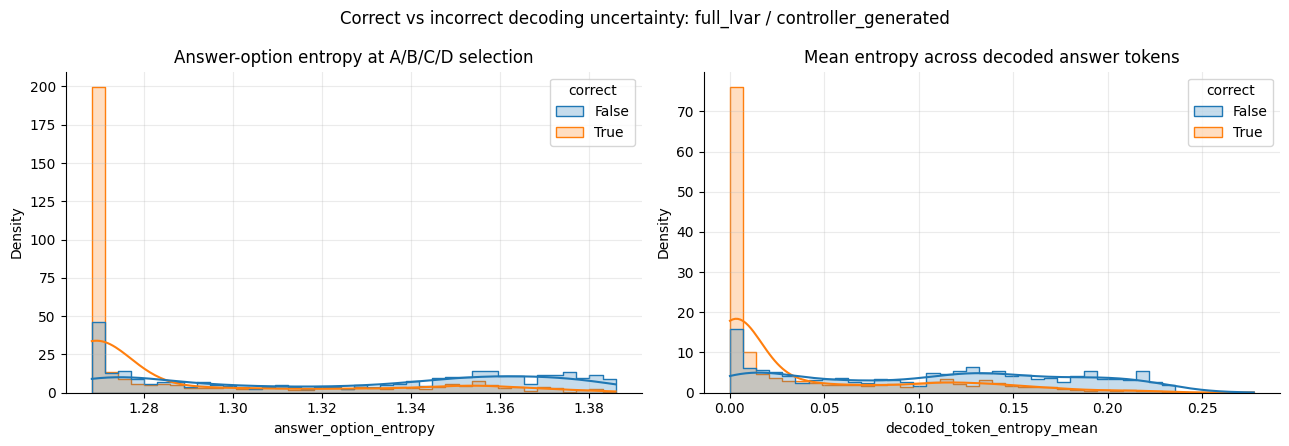

In [29]:
ENTROPY_SELECT_MINED_BY = "full_lvar"
ENTROPY_SELECT_CONTEXT = "global"
ENTROPY_SELECT_EVALUATED_BY = "lvar+controller"
ENTROPY_SELECT_TRACE_VARIANT = "controller_generated"

selected_entropy_run = entropy_df[
    (entropy_df["mined_by"] == ENTROPY_SELECT_MINED_BY)
    & (entropy_df["context"] == ENTROPY_SELECT_CONTEXT)
    & (entropy_df["evaluated_by"] == ENTROPY_SELECT_EVALUATED_BY)
    & (entropy_df["trace_variant"] == ENTROPY_SELECT_TRACE_VARIANT)
].copy()

print(f"Selected entropy rows: {len(selected_entropy_run):,}")
display(selected_entropy_run.groupby("correct")[entropy_metric_cols].agg(["count", "mean", "median", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hist_specs = [
    ("answer_option_entropy", "Answer-option entropy at A/B/C/D selection"),
    ("decoded_token_entropy_mean", "Mean entropy across decoded answer tokens"),
]
for ax, (metric, title) in zip(axes, hist_specs):
    usable = selected_entropy_run.dropna(subset=[metric])
    if HAS_SEABORN:
        sns.histplot(
            data=usable,
            x=metric,
            hue="correct",
            bins=40,
            kde=True,
            stat="density",
            common_norm=False,
            element="step",
            ax=ax,
        )
    else:
        for correct, group in usable.groupby("correct"):
            ax.hist(group[metric], bins=40, alpha=0.45, density=True, label=f"correct={correct}")
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
plt.suptitle(f"Correct vs incorrect decoding uncertainty: {ENTROPY_SELECT_MINED_BY} / {ENTROPY_SELECT_TRACE_VARIANT}")
plt.tight_layout()
plt.show()


### Does Higher Entropy Predict Errors?

For each run, the table reports the incorrect-minus-correct mean entropy gap and a rank AUC. AUC is defined here as the probability that a randomly chosen incorrect sample has higher entropy than a randomly chosen correct sample. `0.5` means no separation; values above `0.5` mean entropy tends to be higher for errors.


In [30]:
def error_detection_auc(frame, metric):
    usable = frame[[metric, "correct"]].dropna()
    if usable["correct"].nunique() < 2:
        return np.nan
    scores = usable[metric]
    error = (~usable["correct"]).astype(int)
    n_error = int(error.sum())
    n_correct = int((1 - error).sum())
    ranks = scores.rank(method="average")
    return float((ranks[error == 1].sum() - n_error * (n_error + 1) / 2) / (n_error * n_correct))


discrimination_rows = []
for run_label, group in entropy_df.groupby("run_label"):
    metadata = group.iloc[0]
    row = {
        "run_type": metadata["run_type"],
        "mined_by": metadata["mined_by"],
        "context": metadata["context"],
        "evaluated_by": metadata["evaluated_by"],
        "trace_variant_label": metadata["trace_variant_label"],
        "samples": len(group),
        "accuracy": group["correct"].mean(),
    }
    for metric in [
        "answer_option_entropy",
        "decoded_token_entropy_mean",
        "decoded_token_entropy_max",
        "controller_action_entropy_mean",
        "controller_region_entropy_mean",
        "controller_patch_entropy_mean",
        "controller_entropy_mean",
    ]:
        means = group.groupby("correct")[metric].mean()
        row[f"{metric}_error_gap"] = means.get(False, np.nan) - means.get(True, np.nan)
        row[f"{metric}_error_auc"] = error_detection_auc(group, metric)
    discrimination_rows.append(row)

entropy_discrimination = pd.DataFrame(discrimination_rows).sort_values(
    ["run_type", "mined_by", "context", "evaluated_by", "trace_variant_label"]
)
entropy_discrimination.style.format({
    "accuracy": "{:.2%}",
    **{c: "{:.4f}" for c in entropy_discrimination.columns if c.endswith("_gap") or c.endswith("_auc")},
}).set_caption("How strongly each entropy metric separates incorrect from correct samples")


,run_type,mined_by,context,evaluated_by,trace_variant_label,samples,accuracy,answer_option_entropy_error_gap,answer_option_entropy_error_auc,decoded_token_entropy_mean_error_gap,decoded_token_entropy_mean_error_auc,decoded_token_entropy_max_error_gap,decoded_token_entropy_max_error_auc,controller_action_entropy_mean_error_gap,controller_action_entropy_mean_error_auc,controller_region_entropy_mean_error_gap,controller_region_entropy_mean_error_auc,controller_patch_entropy_mean_error_gap,controller_patch_entropy_mean_error_auc,controller_entropy_mean_error_gap,controller_entropy_mean_error_auc
0,full_lvar,full_lvar,global,lvar+controller,controller-generated,2318,65.83%,0.0368,0.7903,0.0670,0.7852,0.3965,0.7839,0.0092,0.5240,-0.0344,0.4371,-0.0444,0.4436,0.0092,0.5240
1,oracle,ivtlr,coarse,ivtlr,filtered (cap),2318,51.47%,0.0231,0.6702,0.0438,0.6589,0.2468,0.6673,nan,nan,nan,nan,nan,nan,nan,nan
2,oracle,ivtlr,coarse,ivtlr,filtered (no cap),2318,57.51%,0.0246,0.6838,0.0428,0.6682,0.2564,0.6787,nan,nan,nan,nan,nan,nan,nan,nan
3,oracle,ivtlr,coarse,ivtlr,raw,2318,58.67%,0.0256,0.6901,0.0442,0.6773,0.2688,0.6857,nan,nan,nan,nan,nan,nan,nan,nan
4,oracle,ivtlr,coarse,lvar,filtered (cap),2318,42.49%,0.0162,0.6327,0.0806,0.6150,0.3220,0.6199,nan,nan,nan,nan,nan,nan,nan,nan
5,oracle,ivtlr,coarse,lvar,filtered (no cap),2318,43.74%,0.0171,0.6386,0.0592,0.6167,0.2767,0.6203,nan,nan,nan,nan,nan,nan,nan,nan
6,oracle,ivtlr,coarse,lvar,raw,2318,44.22%,0.0175,0.6395,0.0530,0.6135,0.2585,0.6162,nan,nan,nan,nan,nan,nan,nan,nan
7,oracle,ivtlr,global,ivtlr,filtered (cap),2318,68.68%,0.0392,0.7958,0.0612,0.7516,0.3673,0.7590,nan,nan,nan,nan,nan,nan,nan,nan
8,oracle,ivtlr,global,ivtlr,filtered (no cap),2318,69.41%,0.0397,0.7968,0.0632,0.7547,0.3798,0.7632,nan,nan,nan,nan,nan,nan,nan,nan
9,oracle,ivtlr,global,ivtlr,raw,2318,69.93%,0.0404,0.8004,0.0673,0.7627,0.4033,0.7711,nan,nan,nan,nan,nan,nan,nan,nan


### Accuracy Across Entropy Quantiles

This is a calibration-style view for the selected run. Samples are divided into entropy quintiles independently for each metric; a useful uncertainty signal should generally show lower accuracy in higher-entropy bins.


,entropy_quantile,samples,accuracy,mean_entropy,metric,quantile_rank
0,"(1.26829, 1.26834]",457,96.50%,1.2683,answer_option_entropy,1
1,"(1.26834, 1.2699]",456,83.99%,1.2687,answer_option_entropy,2
2,"(1.2699, 1.29592]",456,61.40%,1.2789,answer_option_entropy,3
3,"(1.29592, 1.35143]",456,53.73%,1.3266,answer_option_entropy,4
4,"(1.35143, 1.38606]",457,34.14%,1.3665,answer_option_entropy,5
5,"(-0.0009774, 0.00101]",464,92.46%,0.0004,decoded_token_entropy_mean,1
6,"(0.00101, 0.00796]",463,87.90%,0.0034,decoded_token_entropy_mean,2
7,"(0.00796, 0.0611]",464,62.07%,0.0287,decoded_token_entropy_mean,3
8,"(0.0611, 0.135]",463,53.13%,0.1026,decoded_token_entropy_mean,4
9,"(0.135, 0.277]",464,33.62%,0.1772,decoded_token_entropy_mean,5


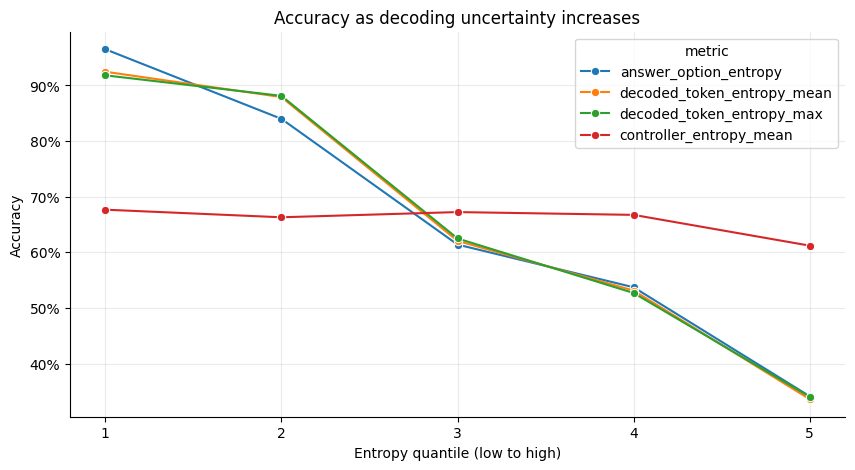

In [31]:
quantile_rows = []
for metric in [
    "answer_option_entropy",
    "decoded_token_entropy_mean",
    "decoded_token_entropy_max",
    "controller_entropy_mean",
]:
    usable = selected_entropy_run.dropna(subset=[metric]).copy()
    if usable[metric].nunique() < 2:
        continue
    usable["entropy_quantile"] = pd.qcut(usable[metric], q=min(5, usable[metric].nunique()), duplicates="drop")
    grouped = usable.groupby("entropy_quantile", observed=True).agg(
        samples=("example_id", "size"),
        accuracy=("correct", "mean"),
        mean_entropy=(metric, "mean"),
    ).reset_index()
    grouped["metric"] = metric
    grouped["entropy_quantile"] = grouped["entropy_quantile"].astype(str)
    grouped["quantile_rank"] = range(1, len(grouped) + 1)
    quantile_rows.append(grouped)

entropy_quantiles = pd.concat(quantile_rows, ignore_index=True) if quantile_rows else pd.DataFrame()
display(entropy_quantiles.style.format({"accuracy": "{:.2%}", "mean_entropy": "{:.4f}"}))

if not entropy_quantiles.empty:
    if HAS_SEABORN:
        sns.lineplot(data=entropy_quantiles, x="quantile_rank", y="accuracy", hue="metric", marker="o")
    else:
        for metric, group in entropy_quantiles.groupby("metric"):
            plt.plot(group["quantile_rank"], group["accuracy"], marker="o", label=metric)
        plt.legend()
    plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.xticks(sorted(entropy_quantiles["quantile_rank"].unique()))
    plt.xlabel("Entropy quantile (low to high)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy as decoding uncertainty increases")
    plt.show()


### Option Entropy vs Answer-Trace Entropy

The scatter plot checks whether uncertainty at final answer selection agrees with uncertainty accumulated throughout decoding. Correctness coloring can reveal distinct failure modes, such as a confident final option following a highly uncertain reasoning trace.


Spearman correlation: 0.9709


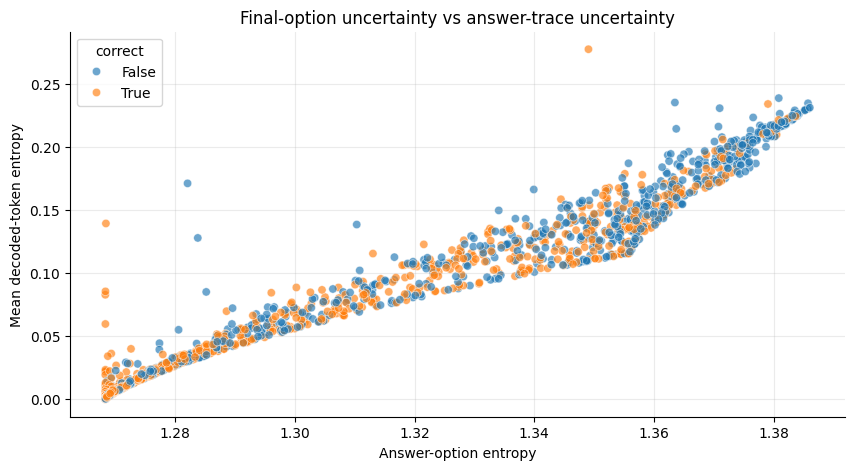

In [32]:
scatter_run = selected_entropy_run.dropna(subset=["answer_option_entropy", "decoded_token_entropy_mean"])
if scatter_run.empty:
    print("No samples have both option and answer-trace entropy for the selected run.")
else:
    correlation = scatter_run[["answer_option_entropy", "decoded_token_entropy_mean"]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman correlation: {correlation:.4f}")
    if HAS_SEABORN:
        sns.scatterplot(
            data=scatter_run,
            x="answer_option_entropy",
            y="decoded_token_entropy_mean",
            hue="correct",
            alpha=0.65,
        )
    else:
        for correct, group in scatter_run.groupby("correct"):
            plt.scatter(group["answer_option_entropy"], group["decoded_token_entropy_mean"], alpha=0.65, label=f"correct={correct}")
        plt.legend()
    plt.xlabel("Answer-option entropy")
    plt.ylabel("Mean decoded-token entropy")
    plt.title("Final-option uncertainty vs answer-trace uncertainty")
    plt.show()


### Controller Entropy in the Full LVAR Pipeline

The controller emits action, region, and patch distributions at every reasoning step. The joint entropy is `H(action) + P(REGION) H(region) + P(PATCH) H(patch)`, which is the entropy of the hierarchical controller decision rather than an unweighted average of differently sized heads. The following analyses ask whether controller uncertainty separates errors, where in the trace uncertainty appears, and whether it varies by action, trace length, or domain.


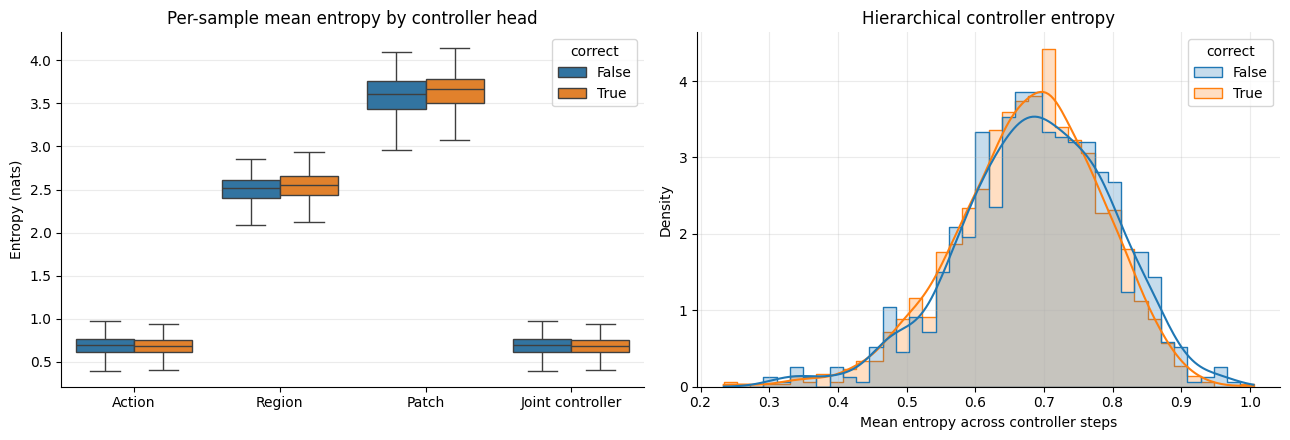

In [33]:
controller_metric_map = {
    "Action": "controller_action_entropy_mean",
    "Region": "controller_region_entropy_mean",
    "Patch": "controller_patch_entropy_mean",
    "Joint controller": "controller_entropy_mean",
}
controller_entropy_run = selected_entropy_run.dropna(subset=["controller_entropy_mean"]).copy()

if controller_entropy_run.empty:
    print("No controller entropy is available for the selected run. Rerun full LVAR inference with controller entropy tracking enabled.")
else:
    controller_long = controller_entropy_run.melt(
        id_vars=["example_id", "correct"],
        value_vars=list(controller_metric_map.values()),
        var_name="metric",
        value_name="entropy",
    )
    controller_long["head"] = controller_long["metric"].map({v: k for k, v in controller_metric_map.items()})
    controller_correctness_summary = (
        controller_long.groupby(["head", "correct"])["entropy"]
        .agg(["count", "mean", "median", "std", lambda s: s.quantile(0.10), lambda s: s.quantile(0.90)])
        .rename(columns={"<lambda_0>": "p10", "<lambda_1>": "p90"})
    )
    display(controller_correctness_summary.style.format({c: "{:.4f}" for c in ["mean", "median", "std", "p10", "p90"]}))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    if HAS_SEABORN:
        sns.boxplot(data=controller_long, x="head", y="entropy", hue="correct", showfliers=False, ax=axes[0])
        sns.histplot(
            data=controller_entropy_run,
            x="controller_entropy_mean",
            hue="correct",
            bins=40,
            kde=True,
            stat="density",
            common_norm=False,
            element="step",
            ax=axes[1],
        )
    else:
        controller_long.pivot_table(index="example_id", columns=["head", "correct"], values="entropy").boxplot(ax=axes[0], rot=30)
        for correct, group in controller_entropy_run.groupby("correct"):
            axes[1].hist(group["controller_entropy_mean"], bins=40, alpha=0.45, density=True, label=f"correct={correct}")
        axes[1].legend()
    axes[0].set_title("Per-sample mean entropy by controller head")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Entropy (nats)")
    axes[1].set_title("Hierarchical controller entropy")
    axes[1].set_xlabel("Mean entropy across controller steps")
    axes[1].set_ylabel("Density")
    plt.tight_layout()
    plt.show()


#### Error Detection and Entropy Quantiles

The AUC below treats higher entropy as evidence of an error. It is the probability that a randomly chosen incorrect sample has higher entropy than a randomly chosen correct sample. The quantile plot complements AUC by showing whether accuracy degrades monotonically as controller uncertainty rises.


,head,incorrect_minus_correct_mean,error_detection_auc,coverage
0,Action,0.0092,0.5240,100.00%
1,Region,-0.0344,0.4371,100.00%
2,Patch,-0.0444,0.4436,100.00%
3,Joint controller,0.0092,0.5240,100.00%


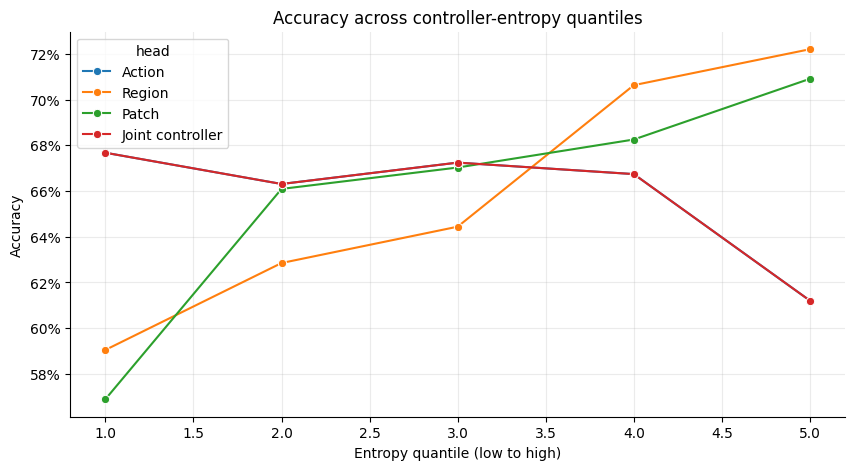

In [34]:
if not controller_entropy_run.empty:
    controller_detection_rows = []
    for label, metric in controller_metric_map.items():
        means = controller_entropy_run.groupby("correct")[metric].mean()
        controller_detection_rows.append({
            "head": label,
            "incorrect_minus_correct_mean": means.get(False, np.nan) - means.get(True, np.nan),
            "error_detection_auc": error_detection_auc(controller_entropy_run, metric),
            "coverage": controller_entropy_run[metric].notna().mean(),
        })
    controller_detection = pd.DataFrame(controller_detection_rows)
    display(controller_detection.style.format({
        "incorrect_minus_correct_mean": "{:.4f}",
        "error_detection_auc": "{:.4f}",
        "coverage": "{:.2%}",
    }))

    controller_quantile_rows = []
    for label, metric in controller_metric_map.items():
        usable = controller_entropy_run.dropna(subset=[metric]).copy()
        if usable[metric].nunique() < 2:
            continue
        usable["entropy_quantile"] = pd.qcut(usable[metric], q=min(5, usable[metric].nunique()), duplicates="drop")
        grouped = usable.groupby("entropy_quantile", observed=True).agg(
            samples=("example_id", "size"),
            accuracy=("correct", "mean"),
            mean_entropy=(metric, "mean"),
        ).reset_index()
        grouped["head"] = label
        grouped["quantile_rank"] = range(1, len(grouped) + 1)
        controller_quantile_rows.append(grouped)
    controller_entropy_quantiles = pd.concat(controller_quantile_rows, ignore_index=True)

    if HAS_SEABORN:
        sns.lineplot(data=controller_entropy_quantiles, x="quantile_rank", y="accuracy", hue="head", marker="o")
    else:
        for head, group in controller_entropy_quantiles.groupby("head"):
            plt.plot(group["quantile_rank"], group["accuracy"], marker="o", label=head)
        plt.legend()
    plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.xlabel("Entropy quantile (low to high)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy across controller-entropy quantiles")
    plt.show()


#### Entropy Through the Controller Trace

This expands each sample into controller steps. It compares uncertainty trajectories for correct and incorrect examples and separates the result by the action selected at that step. A rising error-only trajectory can indicate late indecision; a high first-step gap points instead to uncertainty in initial visual planning.


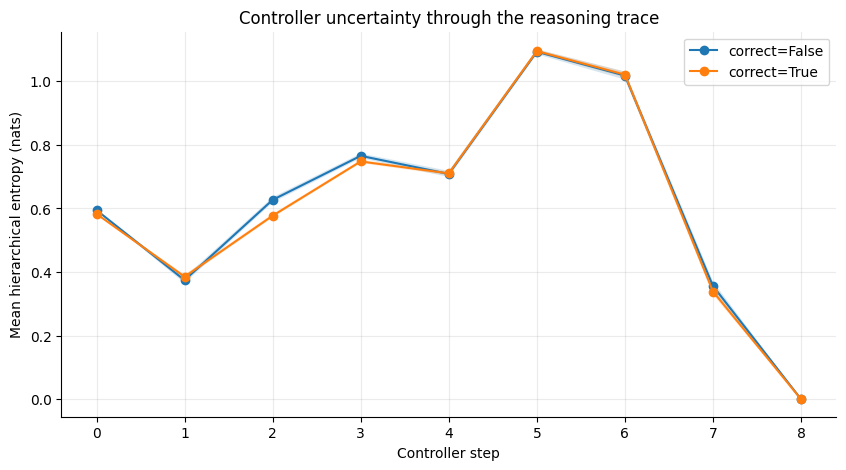

,action,correct,steps,action_entropy,region_entropy,patch_entropy,selected_index_entropy,joint_entropy
0,PATCH,False,2664,0.7890,2.7099,3.6898,3.6898,0.7890
1,PATCH,True,5551,0.7617,2.7254,3.7234,3.7234,0.7617
2,REGION,False,2129,0.6217,2.6511,3.7264,2.6511,0.6217
3,REGION,True,3838,0.6349,2.6825,3.7890,2.6825,0.6349
4,STOP,False,792,0.4323,1.4166,2.8623,nan,0.4323
5,STOP,True,1526,0.4299,1.5038,2.9015,nan,0.4299
6,THINK,False,467,0.8299,2.4556,3.5805,nan,0.8299
7,THINK,True,803,0.7738,2.4623,3.6018,nan,0.7738


In [35]:
controller_action_lookup = (
    predictions[predictions["run_type"] == "full_lvar"]
    .drop_duplicates("example_id")
    .set_index("example_id")["controller_actions"]
    .to_dict()
)
controller_step_rows = []
for _, sample in controller_entropy_run.iterrows():
    actions = controller_action_lookup.get(sample["example_id"], []) or []
    series = {
        "controller_action_entropy": sample.get("controller_action_entropies") or [],
        "controller_region_entropy": sample.get("controller_region_entropies") or [],
        "controller_patch_entropy": sample.get("controller_patch_entropies") or [],
        "controller_entropy": sample.get("controller_entropies") or [],
    }
    num_steps = max([len(values) for values in series.values()] + [len(actions)])
    for step_idx in range(num_steps):
        action = actions[step_idx] if step_idx < len(actions) else "UNKNOWN"
        record = {
            "example_id": sample["example_id"],
            "correct": sample["correct"],
            "step_idx": step_idx,
            "action": action,
        }
        for metric, values in series.items():
            record[metric] = values[step_idx] if step_idx < len(values) else np.nan
        record["selected_index_entropy"] = (
            record["controller_region_entropy"] if action == "REGION"
            else record["controller_patch_entropy"] if action == "PATCH"
            else np.nan
        )
        controller_step_rows.append(record)
controller_step_df = pd.DataFrame(controller_step_rows)

if controller_step_df.empty:
    print("No step-level controller entropy available.")
else:
    step_trajectory = (
        controller_step_df.groupby(["step_idx", "correct"])["controller_entropy"]
        .agg(["count", "mean", "std"])
        .reset_index()
    )
    step_trajectory["sem"] = step_trajectory["std"] / np.sqrt(step_trajectory["count"].clip(lower=1))
    for correct, group in step_trajectory.groupby("correct"):
        group = group.sort_values("step_idx")
        plt.plot(group["step_idx"], group["mean"], marker="o", label=f"correct={correct}")
        plt.fill_between(group["step_idx"], group["mean"] - group["sem"], group["mean"] + group["sem"], alpha=0.18)
    plt.xlabel("Controller step")
    plt.ylabel("Mean hierarchical entropy (nats)")
    plt.title("Controller uncertainty through the reasoning trace")
    plt.legend()
    plt.show()

    action_entropy_summary = (
        controller_step_df.groupby(["action", "correct"])
        .agg(
            steps=("example_id", "size"),
            action_entropy=("controller_action_entropy", "mean"),
            region_entropy=("controller_region_entropy", "mean"),
            patch_entropy=("controller_patch_entropy", "mean"),
            selected_index_entropy=("selected_index_entropy", "mean"),
            joint_entropy=("controller_entropy", "mean"),
        )
        .reset_index()
        .sort_values(["action", "correct"])
    )
    display(action_entropy_summary.style.format({c: "{:.4f}" for c in action_entropy_summary.columns if c.endswith("entropy")}))


#### Trace Length, Domain, and Diagnostic Examples

These views test whether entropy merely proxies for longer controller traces, identify domains where controller uncertainty is concentrated, and surface confident mistakes or uncertain successes for qualitative inspection.


,controller_entropy_mean,controller_action_entropy_mean,controller_region_entropy_mean,controller_patch_entropy_mean,num_controller_steps,num_output_tokens
controller_entropy_mean,1.000,1.000,0.253,0.355,-0.083,-0.017
controller_action_entropy_mean,1.000,1.000,0.253,0.355,-0.083,-0.017
controller_region_entropy_mean,0.253,0.253,1.000,0.637,-0.333,0.011
controller_patch_entropy_mean,0.355,0.355,0.637,1.000,0.026,-0.003
num_controller_steps,-0.083,-0.083,-0.333,0.026,1.000,0.007
num_output_tokens,-0.017,-0.017,0.011,-0.003,0.007,1.000


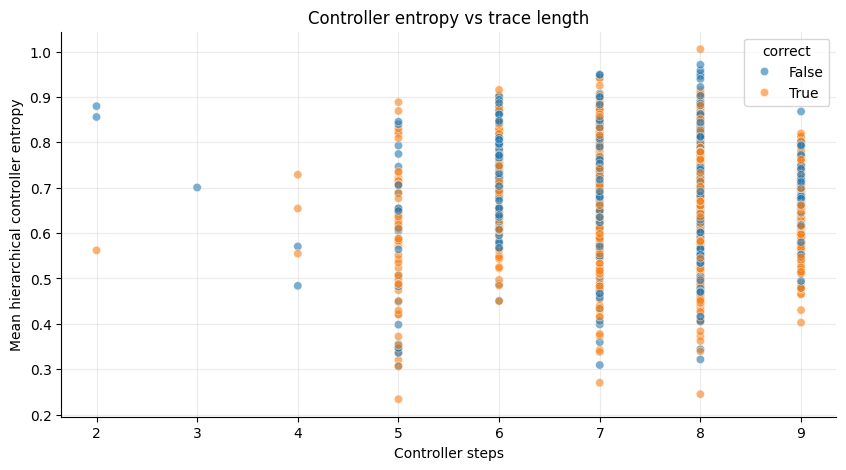

,domain,samples,accuracy,mean_controller_entropy,mean_action_entropy,mean_steps
2,science,1622,64.67%,0.6994,0.6994,7.70
0,commonsense,455,75.38%,0.6029,0.6029,7.56
1,mathematics,241,55.60%,0.7038,0.7038,7.66


Confident errors: incorrect samples with the lowest controller entropy


,example_id,domain,topic,gold_answer,generated_text,controller_entropy_mean,controller_action_entropy_mean,num_controller_steps
164,social-commonsense-1729,commonsense,social-commonsense,a,"Therefore, the answer is B",0.306309,0.306309,5
12,physical-commonsense-1394,commonsense,physical-commonsense,a,"Therefore, the answer is C",0.309017,0.309017,7
221,social-commonsense-360,commonsense,social-commonsense,c,"Therefore, the answer is B",0.321427,0.321427,8
260,social-commonsense-395,commonsense,social-commonsense,c,"Therefore, the answer is B",0.335738,0.335738,5
111,social-commonsense-172,commonsense,social-commonsense,a,"Therefore, the answer is B",0.343939,0.343939,8
194,social-commonsense-764,commonsense,social-commonsense,d,"Therefore, the answer is A",0.345523,0.345523,5
270,social-commonsense-1732,commonsense,social-commonsense,a,"Therefore, the answer is D",0.346723,0.346723,5
15,physical-commonsense-1436,commonsense,physical-commonsense,b,"Therefore, the answer is C",0.355154,0.355154,5
242,social-commonsense-471,commonsense,social-commonsense,c,"Therefore, the answer is B",0.359577,0.359577,7
129,social-commonsense-91,commonsense,social-commonsense,c,"Therefore, the answer is B",0.398124,0.398124,5


Uncertain successes: correct samples with the highest controller entropy


,example_id,domain,topic,gold_answer,generated_text,controller_entropy_mean,controller_action_entropy_mean,num_controller_steps
1875,economics-329,science,social-science,c,"Therefore, the answer is C",1.005184,1.005184,8
1257,physics-68,science,natural-science,c,"Therefore, the answer is C",0.942225,0.942225,7
568,mathematics-696,mathematics,algebra,c,"Therefore, the answer is C",0.939914,0.939914,7
1504,physical-commonsense-294,science,natural-science,c,"Therefore, the answer is C",0.924924,0.924924,7
1918,economics-645,science,social-science,b,"Therefore, the answer is B",0.915607,0.915607,6
724,grammar-135,science,language-science,b,"Therefore, the answer is B",0.915076,0.915076,8
1187,chemistry-165,science,natural-science,c,"Therefore, the answer is C",0.911176,0.911176,8
1713,cognitive-science-380,science,social-science,c,"Therefore, the answer is C",0.907397,0.907397,8
1290,physics-25,science,natural-science,a,"Therefore, the answer is A",0.904766,0.904766,7
1269,physics-1008,science,natural-science,b,"Therefore, the answer is B",0.903640,0.903640,6


In [36]:
controller_metadata = (
    predictions[predictions["run_type"] == "full_lvar"]
    .drop_duplicates("example_id")
    [["example_id", "domain", "topic", "generated_text", "gold_answer", "num_inference_trace_actions", "num_output_tokens"]]
)
controller_samples = controller_entropy_run.merge(controller_metadata, on="example_id", how="left", suffixes=("", "_prediction"))
controller_samples["num_controller_steps"] = controller_samples["controller_entropies"].map(lambda x: len(x) if isinstance(x, list) else np.nan)

if not controller_samples.empty:
    relationship_cols = ["controller_entropy_mean", "controller_action_entropy_mean", "controller_region_entropy_mean", "controller_patch_entropy_mean", "num_controller_steps", "num_output_tokens"]
    controller_correlations = controller_samples[relationship_cols].corr(method="spearman")
    display(controller_correlations.style.format("{:.3f}").set_caption("Spearman correlations among entropy and sequence lengths"))

    if HAS_SEABORN:
        sns.scatterplot(data=controller_samples, x="num_controller_steps", y="controller_entropy_mean", hue="correct", alpha=0.6)
    else:
        for correct, group in controller_samples.groupby("correct"):
            plt.scatter(group["num_controller_steps"], group["controller_entropy_mean"], alpha=0.6, label=f"correct={correct}")
        plt.legend()
    plt.xlabel("Controller steps")
    plt.ylabel("Mean hierarchical controller entropy")
    plt.title("Controller entropy vs trace length")
    plt.show()

    controller_domain_summary = (
        controller_samples.groupby("domain", dropna=False)
        .agg(
            samples=("example_id", "size"),
            accuracy=("correct", "mean"),
            mean_controller_entropy=("controller_entropy_mean", "mean"),
            mean_action_entropy=("controller_action_entropy_mean", "mean"),
            mean_steps=("num_controller_steps", "mean"),
        )
        .reset_index()
        .sort_values("samples", ascending=False)
    )
    display(controller_domain_summary.style.format({"accuracy": "{:.2%}", "mean_controller_entropy": "{:.4f}", "mean_action_entropy": "{:.4f}", "mean_steps": "{:.2f}"}))

    diagnostic_cols = ["example_id", "domain", "topic", "gold_answer", "generated_text", "controller_entropy_mean", "controller_action_entropy_mean", "num_controller_steps"]
    print("Confident errors: incorrect samples with the lowest controller entropy")
    display(controller_samples[~controller_samples["correct"]].nsmallest(12, "controller_entropy_mean")[diagnostic_cols])
    print("Uncertain successes: correct samples with the highest controller entropy")
    display(controller_samples[controller_samples["correct"]].nlargest(12, "controller_entropy_mean")[diagnostic_cols])


## 5. Error And Success Examples For Inspection

These tables surface examples where trace mining strongly reduced CE but inference was still wrong, and examples that were correct despite weak or low CE reduction. They are useful candidates for qualitative trace inspection.

In [37]:
def compact_question(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r"\s+", " ", text).strip()
    return text[:260] + ("..." if len(text) > 260 else "")

inspection_cols = [
    "example_id", "topic", "gold_answer", "generated_text", "raw_answer", "total_ce_reduction",
    "num_trace_actions", "num_patches", "num_regions", "num_noop_decisions", "question"
]

if selected_run.empty:
    print("No rows for the selected run. Adjust SELECT_* variables above.")
else:
    display_run = selected_run.copy()
    display_run["question"] = display_run["question"].map(compact_question)

    print("Wrong despite high mined CE reduction")
    display(display_run[~display_run["correct"]].sort_values("total_ce_reduction", ascending=False)[inspection_cols].head(15))

    print("Correct despite low mined CE reduction")
    display(display_run[display_run["correct"]].sort_values("total_ce_reduction", ascending=True)[inspection_cols].head(15))

Wrong despite high mined CE reduction


,example_id,topic,gold_answer,generated_text,raw_answer,total_ce_reduction,num_trace_actions,num_patches,num_regions,num_noop_decisions,question
11716,social-commonsense-1619,social-commonsense,b,"Therefore, the answer is A",B,1.982545,9.0,5.0,4.0,0.0,[Question]:{Where is the tennis player most likely playing?} [Options]: (A).{In a professional match at a tournament} (B).{In a casual m...
12262,mathematics-879,geometry,c,"Therefore, the answer is D",C,1.770263,7.0,0.0,5.0,1.0,"[Question]:{If you had to select one option as the correct answer for the Geometry problem shown in the picture, which one would you cho..."
12024,mathematics-1911,temporal-commonsense,d,"Therefore, the answer is C",D,1.519095,14.0,10.0,3.0,0.0,[Question]:{Look at the following schedule. Hayley just missed the 11.45 AM bus at the boat docks. How long does she have to wait until ...
12534,biology-1053,natural-science,a,"Therefore, the answer is B",A,1.417576,14.0,8.0,5.0,1.0,"[Question]:{Based on this information, what is Alfalfa's genotype for the horns gene?} [Options]: (A).{HH} (B).{hh} (C).{Hh} Answer:"
11846,social-commonsense-298,social-commonsense,b,"Therefore, the answer is D",B,1.416366,10.0,9.0,0.0,0.0,"[Question]:{Based on the image, which of the following statements is most likely true about the person who ordered this food?} [Options]..."
12043,mathematics-1597,temporal-commonsense,b,"Therefore, the answer is D",B,1.386698,12.0,7.0,3.0,0.0,"[Question]:{Franklin is at the art gallery district. If he wants to arrive at the baseball stadium at 12.00 PM, what time should he get ..."
12376,reading-comprehension-20,language-science,a,"Therefore, the answer is B",A,1.373230,10.0,5.0,4.0,1.0,[Question]:{How do sea otters use their pockets?} [Options]: (A).{Option A in the image} (B).{Option B in the image} (C).{It seems like ...
12552,biology-180,natural-science,d,"Therefore, the answer is A",D,1.334466,10.0,5.0,4.0,1.0,"[Question]:{Based on this information, what is Bianca's genotype for the eye color gene?} [Options]: (A).{AA} (B).{ee} (C).{Ee} (D).{EE}..."
12399,writing-strategies-101,language-science,b,"Therefore, the answer is A",B,1.316325,17.0,13.0,3.0,0.0,[Question]:{Which of the following contains a vague pronoun reference?} [Options]: (A).{Option A in the image} (B).{Option B in the imag...
13727,geography-1252,social-science,a,"Therefore, the answer is C",A,1.305454,8.0,6.0,1.0,0.0,[Question]:{Which of the following fossils is older? Select the more likely answer.} [Options]: (A).{crocodile egg} (B).{fern} (C).{They...


Correct despite low mined CE reduction


,example_id,topic,gold_answer,generated_text,raw_answer,total_ce_reduction,num_trace_actions,num_patches,num_regions,num_noop_decisions,question
11953,mathematics-1580,temporal-commonsense,a,"Therefore, the answer is A",A,0.0,0.0,0.0,0.0,2.0,[Question]:{Look at the following schedule. When does the shark lecture end?} [Options]: (A).{8:50 AM} (B).{12:10 PM} (C).{12:15 PM} (D)...
12050,mathematics-470,algebra,a,"Therefore, the answer is A",A,0.0,0.0,0.0,0.0,2.0,"[Question]:{Among the provided choices given in the text, which one represents the accurate answer to the Intermediate Algebra problem i..."
11950,mathematics-1716,temporal-commonsense,c,"Therefore, the answer is C",C,0.0,0.0,0.0,0.0,2.0,[Question]:{Look at the following schedule. When does the Hawks versus Jaguars game begin?} [Options]: (A).{9:50 AM} (B).{1:55 PM} (C).{...
12104,mathematics-1346,algebra,b,"Therefore, the answer is B",B,0.0,0.0,0.0,0.0,2.0,"[Question]:{According to the following questions, is option D in the image correct?} [Options]: (A).{False} (B).{True} (C).{Not sure} An..."
12109,mathematics-68,algebra,a,"Therefore, the answer is A",A,0.0,0.0,0.0,0.0,4.0,"[Question]:{Among the provided choices given in the text, which one represents the accurate answer to the Algebra problem illustrated in..."
12121,mathematics-98,algebra,a,"Therefore, the answer is A",A,0.0,0.0,0.0,0.0,4.0,[Question]:{This Algebra question has multiple choices given in the text. Which one should I choose?} [Options]: (A).{The listed choices...
13314,cognitive-science-43,social-science,d,"Therefore, the answer is D",D,0.0,0.0,0.0,0.0,3.0,[Question]:{What does the tangram image depict?} [Options]: (A).{A box} (B).{A goose} (C).{A box with a goose} (D).{A goose with a box} ...
13317,cognitive-science-195,social-science,b,"Therefore, the answer is B",B,0.0,0.0,0.0,0.0,3.0,[Question]:{What does the Tangram image represent?} [Options]: (A).{A chef} (B).{A geisha girl} (C).{A doctor} (D).{A firefighter} Answer:
11692,social-commonsense-465,social-commonsense,c,"Therefore, the answer is C",C,0.0,0.0,0.0,0.0,2.0,[Question]:{Where are the people most likely going?} [Options]: (A).{Work} (B).{School} (C).{Sightseeing} (D).{Shopping} Answer:
11838,social-commonsense-1597,social-commonsense,d,"Therefore, the answer is D",D,0.0,0.0,0.0,0.0,4.0,[Question]:{Which activity was most likely happening in this room before the photo was taken?} [Options]: (A).{Sleeping} (B).{Watching T...


## 6. Domain And Topic Breakdown

This checks whether trace benefit and final correctness vary across M3CoT domains/topics. It can help identify whether a trace setting is helping visual grounding broadly or only for a subset.

In [38]:
domain_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "evaluated_by", "trace_variant_label", "domain"])
    .agg(
        examples=("example_id", "nunique"),
        accuracy=("correct", "mean"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
    )
    .reset_index()
)
domain_summary["accuracy_pct"] = 100 * domain_summary["accuracy"]
domain_summary.sort_values(["trace_variant_label", "accuracy"], ascending=[True, False]).head(40).style.format({
    "accuracy": "{:.4f}",
    "accuracy_pct": "{:.2f}",
    "mean_total_ce_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
})

,mined_by,context,evaluated_by,trace_variant_label,domain,examples,accuracy,mean_total_ce_reduction,mean_trace_actions,accuracy_pct
0,full_lvar,global,lvar+controller,controller-generated,commonsense,455,0.7538,nan,nan,75.38
2,full_lvar,global,lvar+controller,controller-generated,science,1622,0.6467,nan,nan,64.67
1,full_lvar,global,lvar+controller,controller-generated,mathematics,241,0.5560,nan,nan,55.60
21,ivtlr,global,ivtlr,filtered (cap),commonsense,455,0.7692,0.4725,6.24,76.92
66,lvar,global,lvar,filtered (cap),commonsense,455,0.7670,0.5599,6.25,76.70
57,lvar,global,ivtlr,filtered (cap),commonsense,455,0.7560,0.5599,6.25,75.60
30,ivtlr,global,lvar,filtered (cap),commonsense,455,0.6989,0.4725,6.24,69.89
23,ivtlr,global,ivtlr,filtered (cap),science,1622,0.6708,0.4455,8.30,67.08
68,lvar,global,lvar,filtered (cap),science,1622,0.6671,0.4679,8.53,66.71
59,lvar,global,ivtlr,filtered (cap),science,1622,0.6504,0.4679,8.53,65.04


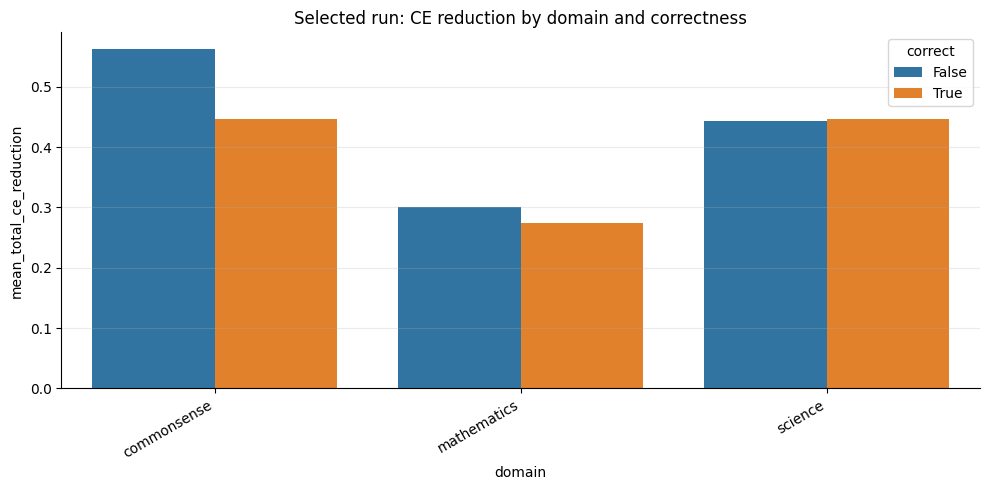

In [39]:
if not selected_run.empty and "domain" in selected_run:
    domain_selected = (
        selected_run
        .groupby(["domain", "correct"])
        .agg(examples=("example_id", "nunique"), mean_total_ce_reduction=("total_ce_reduction", "mean"))
        .reset_index()
    )
    if HAS_SEABORN:
        sns.barplot(data=domain_selected, x="domain", y="mean_total_ce_reduction", hue="correct")
        plt.xticks(rotation=30, ha="right")
        plt.title("Selected run: CE reduction by domain and correctness")
        plt.tight_layout()
        plt.show()
    else:
        domain_selected.pivot_table(index="domain", columns="correct", values="mean_total_ce_reduction").plot(kind="bar", figsize=(10, 5))
        plt.ylabel("Mean total CE reduction")
        plt.tight_layout()
        plt.show()

## 7. Export Analysis Tables

Optional: write the core dataframes as CSVs for reporting or deeper offline analysis.

In [40]:
EXPORT_TABLES = False
EXPORT_DIR = ROOT / "analysis/test_trace_answer_analysis_tables"

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    accuracy_df.to_csv(EXPORT_DIR / "accuracy_by_setting.csv", index=False)
    trace_manifest.to_csv(EXPORT_DIR / "trace_manifest.csv", index=False)
    trace_overview.to_csv(EXPORT_DIR / "trace_overview.csv", index=False)
    ce_summary.to_csv(EXPORT_DIR / "ce_summary.csv", index=False)
    correctness_summary.to_csv(EXPORT_DIR / "correctness_trace_summary.csv", index=False)
    domain_summary.to_csv(EXPORT_DIR / "domain_summary.csv", index=False)
    entropy_df.drop(columns=["answer_option_probabilities", "decoded_token_entropies"], errors="ignore").to_csv(EXPORT_DIR / "entropy_by_sample.csv", index=False)
    entropy_summary.to_csv(EXPORT_DIR / "entropy_summary.csv", index=False)
    entropy_discrimination.to_csv(EXPORT_DIR / "entropy_discrimination.csv", index=False)
    print(f"Wrote tables to {EXPORT_DIR}")
else:
    print("Set EXPORT_TABLES = True to write CSV outputs.")

Set EXPORT_TABLES = True to write CSV outputs.
